# Notebook 05b: Full-Scale RF Analysis — Ridge Batch (Fast)

Replaces the per-neuron STA loop from notebook 05 with the vectorised
`batch_extract_spatial_parameters()` from the updated `sparse_noise.py`.

## What changed

| Bottleneck | Old (nb05) | New (nb05b) |
|------------|-----------|-------------|
| NWB reads | `get_dff_traces()` × n_neurons | `get_dff_traces(all_ids)` × 1 |
| Design matrix | Python loop over ~3,000 presentations | Fully vectorised numpy |
| Ridge fitting | `RidgeCV(cv=5)` × n_neurons — k-fold per neuron | `RidgeCV(cv=None, alpha_per_target=True)` — GCV, SVD shared |
| **Wall-clock** | ~8 h total | **~1 h total** |

## Output files — separate from STA results

```
outputs/rf_params/
├── ridge/
│   ├── rf_params_ridge_container_{id}.csv   ← per-container (crash-safe)
│   └── rf_params_ridge_all_containers.csv   ← combined
└── rf_params_all_containers.csv             ← old STA results (untouched)
```

The STA CSVs are **never touched**. Both pipelines can coexist.

## Analysis pipeline
1. Batch extraction — σ, θ, κ via ridge + Gaussian fit, per container
2. Population distributions + cascade smoothing test
3. Cortical position analysis — spatial autocorrelation of κ
4. Scale–elongation coupling
5. Optional: compare ridge vs STA yields and parameters (if old CSVs exist)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, circstd
from scipy.spatial.distance import pdist, squareform
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import sys, os, warnings, time
from pathlib import Path
from matplotlib.patches import Ellipse

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    reconstruct_rf, fit_gaussian_derivative, extract_spatial_parameters,
    batch_extract_spatial_parameters, gaussian_2d,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
warnings.filterwarnings('ignore')

print('✓ Imports successful')

✓ Imports successful


In [2]:
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
ridge_dir   = outputs_dir / 'ridge'   # ← separate from STA outputs
ridge_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Load experiment metadata
batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())

complete_ids = set(container_meta['container_id'].tolist())
session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()

print(f'✓ Complete containers : {len(complete_ids)}')
print(f'✓ Session C to process: {len(session_c)}')
print(f'✓ Expected neurons    : ~{container_meta["n_neurons"].sum():,}')
print(f'✓ Ridge output dir    : {ridge_dir}')
print(f'  (STA outputs at     : {outputs_dir}  — untouched)')

✓ Complete containers : 17
✓ Session C to process: 17
✓ Expected neurons    : ~3,669
✓ Ridge output dir    : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge
  (STA outputs at     : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params  — untouched)


---

## Part 1: Batch Ridge Extraction

One call to `batch_extract_spatial_parameters(dataset, all_cell_ids)` per container.
Per-container CSV saved immediately after fitting — safe to interrupt and resume.

Output filenames use `ridge` prefix so they never collide with existing STA CSVs.

In [3]:
QUALITY_THRESHOLD = 0.3
PIXEL_SIZE_UM     = 0.78   # μm per pixel, standard Allen 2P

batch_log = []
t_start   = time.time()

for row_i, exp_row in session_c.iterrows():
    container_id = exp_row['experiment_container_id']
    exp_id       = exp_row['id']
    cre_line     = exp_row['cre_line']
    depth        = exp_row['imaging_depth']

    out_file = ridge_dir / f'rf_params_ridge_container_{container_id}.csv'

    # --- Skip if already done ---
    if out_file.exists():
        df_existing = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_existing)} neurons (cached)')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': len(df_existing), 'status': 'cached'})
        continue

    print(f'\n[{row_i+1}/{len(session_c)}] Container {container_id}'
          f'  |  exp {exp_id}  |  {cre_line}  |  {depth} μm')

    try:
        t0      = time.time()
        dataset  = boc.get_ophys_experiment_data(exp_id)
        cell_ids = dataset.get_cell_specimen_ids()
        print(f'  Neurons in container: {len(cell_ids)}')

        # ── single batch call — vectorised NWB read + GCV ridge ──────────────
        results = batch_extract_spatial_parameters(
            dataset, cell_ids,
            quality_threshold=QUALITY_THRESHOLD
        )
        # results is a list of dicts (neurons that passed R² threshold)

        if not results:
            print(f'  WARNING: 0 neurons passed threshold — check data')
            batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                              'cre_line': cre_line, 'depth': depth,
                              'n_success': 0, 'status': 'no_results'})
            continue

        df_out = pd.DataFrame(results)

        # --- Cortical xy from ROI centroids ---
        roi_masks   = dataset.get_roi_mask_array()           # (n_cells, h, w)
        roi_ids_all = dataset.get_cell_specimen_ids()        # ordered same as masks
        fitted_ids  = df_out['cell_id'].tolist()

        cx_um, cy_um = [], []
        for cid in fitted_ids:
            idx = list(roi_ids_all).index(cid)
            mask = roi_masks[idx]
            ys, xs = np.where(mask > 0)
            if len(xs):
                cx_um.append(xs.mean() * PIXEL_SIZE_UM)
                cy_um.append(ys.mean() * PIXEL_SIZE_UM)
            else:
                cx_um.append(np.nan)
                cy_um.append(np.nan)

        df_out['cortex_x_um'] = cx_um
        df_out['cortex_y_um'] = cy_um

        # --- Container metadata ---
        df_out['container_id'] = container_id
        df_out['exp_id']       = exp_id
        df_out['cre_line']     = cre_line
        df_out['depth_um']     = depth

        df_out.to_csv(out_file, index=False)
        elapsed = time.time() - t0
        n_total = len(cell_ids)
        n_fit   = len(df_out)
        print(f'  ✓ {n_fit}/{n_total} neurons passed R²≥{QUALITY_THRESHOLD}'
              f'  ({100*n_fit/n_total:.1f}%)  |  {elapsed:.1f}s')

        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_total': n_total, 'n_success': n_fit,
                          'elapsed_s': round(elapsed, 1), 'status': 'done'})

    except Exception as e:
        print(f'  ERROR container {container_id}: {e}')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': 0, 'status': f'error: {str(e)[:80]}'})

total_elapsed = time.time() - t_start
log_df = pd.DataFrame(batch_log)
print(f'\n✓ Batch complete — {total_elapsed/60:.1f} min total')
print(f'  Done: {(log_df["status"]=="done").sum()}  '
      f'Cached: {(log_df["status"]=="cached").sum()}  '
      f'Errors: {log_df["status"].str.startswith("error").sum()}')

  [SKIP] Container 650389885: 24 neurons (cached)
  [SKIP] Container 511510670: 41 neurons (cached)
  [SKIP] Container 511507650: 55 neurons (cached)
  [SKIP] Container 652842570: 68 neurons (cached)
  [SKIP] Container 511510650: 14 neurons (cached)
  [SKIP] Container 653125128: 74 neurons (cached)
  [SKIP] Container 511509529: 38 neurons (cached)
  [SKIP] Container 661732156: 116 neurons (cached)
  [SKIP] Container 511510718: 36 neurons (cached)
  [SKIP] Container 666589599: 35 neurons (cached)
  [SKIP] Container 688678764: 109 neurons (cached)
  [SKIP] Container 701412138: 35 neurons (cached)
  [SKIP] Container 682734790: 46 neurons (cached)
  [SKIP] Container 680156909: 60 neurons (cached)
  [SKIP] Container 661437138: 50 neurons (cached)
  [SKIP] Container 511510736: 21 neurons (cached)
  [SKIP] Container 511510855: 56 neurons (cached)

✓ Batch complete — 0.0 min total
  Done: 0  Cached: 17  Errors: 0


In [4]:
# --- Load and combine all ridge CSVs ---
csv_files = sorted(ridge_dir.glob('rf_params_ridge_container_*.csv'))
print(f'Found {len(csv_files)} ridge container files')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    if 'container_id' not in df.columns:
        df['container_id'] = int(f.stem.split('_')[-1])
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

for col in ['sigma', 'theta', 'kappa', 'r_squared', 'rmse',
            'cortex_x_um', 'cortex_y_um', 'ridge_lambda', 'best_lag']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

print(f'\n✓ Combined ridge dataset: {len(all_df):,} neurons'
      f' across {all_df["container_id"].nunique()} containers')
print(f'  Cre lines: {all_df["cre_line"].unique()}')
print(f'  Depths   : {sorted(all_df["depth_um"].unique())} μm')
print(f'  Method   : {all_df["method"].unique()}')
print(f'\nColumn overview:')
print(all_df[['sigma','theta','kappa','r_squared',
              'ridge_lambda','best_lag','cortex_x_um']].describe().round(3))

Found 17 ridge container files

✓ Combined ridge dataset: 878 neurons across 17 containers
  Cre lines: ['Cux2-CreERT2' 'Slc17a7-IRES2-Cre']
  Depths   : [175, 205] μm
  Method   : ['ridge_batch']

Column overview:
         sigma    theta    kappa  r_squared  ridge_lambda  best_lag  \
count  878.000  878.000  878.000    878.000       878.000   878.000   
mean     6.610  100.468    1.672      0.523      9170.498     0.449   
std      2.246   74.535    0.640      0.153     22449.946     0.576   
min      2.697    0.000    1.006      0.300       237.137     0.000   
25%      5.207   13.074    1.290      0.390       908.518     0.000   
50%      5.955  133.650    1.469      0.499      1778.279     0.000   
75%      7.291  173.327    1.851      0.633      3480.701     1.000   
max     19.152  180.000    7.290      0.937    100000.000     7.000   

       cortex_x_um  
count      878.000  
mean       197.111  
std        103.708  
min         11.094  
25%        111.677  
50%        199.477 

---

## Part 2: Ridge-Specific Diagnostics

Before the main Lindeberg analysis, check the ridge fit internals:
- **Best lag distribution** — should peak at 0 if `response_delay=4` is well calibrated
- **λ distribution** — neurons hitting the ceiling (λ = 1e5) may be over-regularised
- **R² distribution** — compare to STA baseline if old CSVs exist

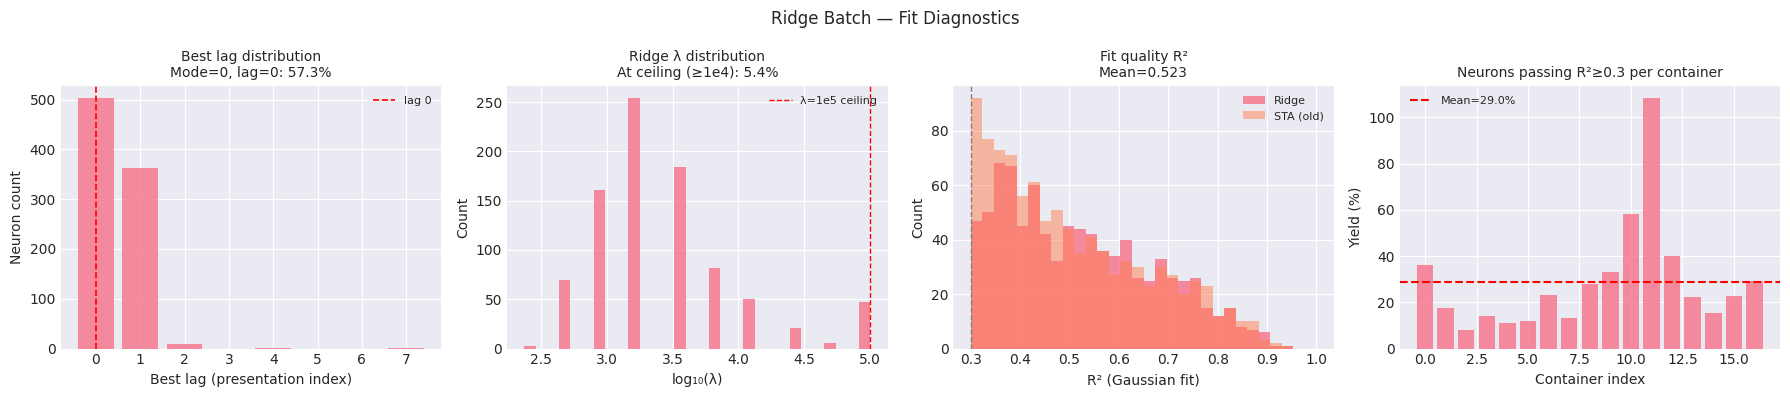

✓ Saved: fig_ridge_diagnostics.png


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# ── Best lag ──────────────────────────────────────────────────────────────────
ax = axes[0]
if 'best_lag' in all_df.columns:
    lag_counts = all_df['best_lag'].value_counts().sort_index()
    ax.bar(lag_counts.index, lag_counts.values, edgecolor='none', alpha=0.8)
    ax.set_xlabel('Best lag (presentation index)', fontsize=10)
    ax.set_ylabel('Neuron count', fontsize=10)
    mode_lag = int(all_df['best_lag'].mode()[0])
    frac_lag0 = (all_df['best_lag'] == 0).mean() * 100
    ax.set_title(f'Best lag distribution\nMode={mode_lag}, lag=0: {frac_lag0:.1f}%', fontsize=10)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='lag 0')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'best_lag not in data', ha='center', va='center',
            transform=ax.transAxes)

# ── Ridge λ ───────────────────────────────────────────────────────────────────
ax = axes[1]
if 'ridge_lambda' in all_df.columns:
    lam = all_df['ridge_lambda'].dropna()
    ax.hist(np.log10(lam + 1e-3), bins=30, edgecolor='none', alpha=0.8)
    frac_ceiling = (lam >= 9e4).mean() * 100   # at or near 1e5 ceiling
    ax.set_xlabel('log₁₀(λ)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Ridge λ distribution\nAt ceiling (≥1e4): {frac_ceiling:.1f}%', fontsize=10)
    ax.axvline(5, color='red', linestyle='--', linewidth=1, label='λ=1e5 ceiling')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'ridge_lambda not in data', ha='center', va='center',
            transform=ax.transAxes)

# ── R² distribution ───────────────────────────────────────────────────────────
ax = axes[2]
ax.hist(all_df['r_squared'].dropna(), bins=30, range=(0.3, 1.0),
        edgecolor='none', alpha=0.8, label='Ridge')

# Overlay STA R² if old combined file exists
sta_combined = outputs_dir / 'rf_params_all_containers.csv'
if sta_combined.exists():
    sta_df = pd.read_csv(sta_combined)
    ax.hist(sta_df['r_squared'].dropna(), bins=30, range=(0.3, 1.0),
            edgecolor='none', alpha=0.5, label='STA (old)', color='coral')
    ax.legend(fontsize=8)

ax.axvline(0.3, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('R² (Gaussian fit)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title(f'Fit quality R²\nMean={all_df["r_squared"].mean():.3f}', fontsize=10)

# ── Yield per container ───────────────────────────────────────────────────────
ax = axes[3]
yield_df = all_df.groupby('container_id').agg(
    n_ridge=('sigma', 'count')
).reset_index()
if 'n_neurons' in container_meta.columns:
    yield_df = yield_df.merge(
        container_meta[['container_id', 'n_neurons']], on='container_id', how='left'
    )
    yield_df['yield_pct'] = 100 * yield_df['n_ridge'] / yield_df['n_neurons']
    ax.bar(range(len(yield_df)), yield_df['yield_pct'], edgecolor='none', alpha=0.8)
    ax.axhline(yield_df['yield_pct'].mean(), color='red', linestyle='--',
               label=f'Mean={yield_df["yield_pct"].mean():.1f}%')
    ax.set_ylabel('Yield (%)', fontsize=10)
    ax.set_title(f'Neurons passing R²≥0.3 per container', fontsize=10)
else:
    ax.bar(range(len(yield_df)), yield_df['n_ridge'], edgecolor='none', alpha=0.8)
    ax.set_ylabel('n neurons', fontsize=10)
    ax.set_title('Neurons passing R²≥0.3 per container', fontsize=10)
ax.set_xlabel('Container index', fontsize=10)
ax.legend(fontsize=8)

fig.suptitle('Ridge Batch — Fit Diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig(ridge_dir / 'fig_ridge_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_ridge_diagnostics.png')

---

## Part 3: Population Parameter Distributions (Lindeberg)

Same analysis as notebook 05, now on the ridge-derived parameters.

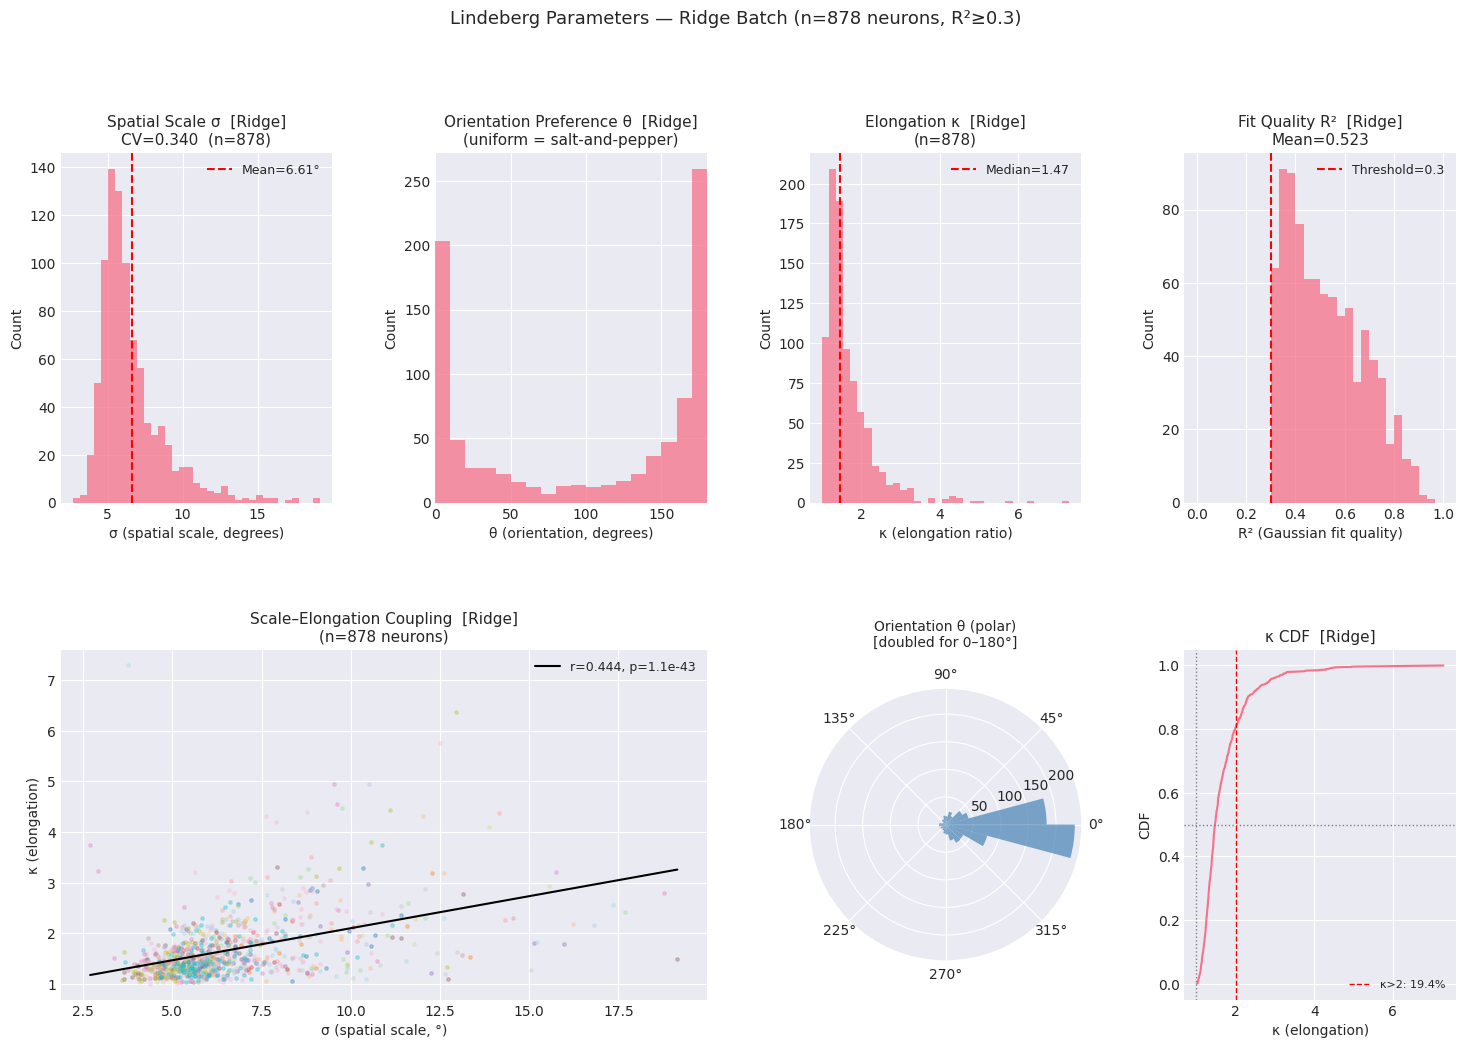

✓ Saved: fig_ridge_parameter_distributions.png


In [6]:
sigma_cv = all_df['sigma'].std() / all_df['sigma'].mean()

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

# σ
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(all_df['sigma'].dropna(), bins=35, edgecolor='none', alpha=0.75)
ax0.axvline(all_df['sigma'].mean(), color='red', linestyle='--',
            label=f"Mean={all_df['sigma'].mean():.2f}°")
ax0.set_xlabel('σ (spatial scale, degrees)', fontsize=10)
ax0.set_ylabel('Count')
ax0.set_title(f'Spatial Scale σ  [Ridge]\nCV={sigma_cv:.3f}  (n={all_df["sigma"].notna().sum():,})', fontsize=11)
ax0.legend(fontsize=9)

# θ
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(all_df['theta'].dropna(), bins=18, range=(0, 180), edgecolor='none', alpha=0.75)
ax1.set_xlabel('θ (orientation, degrees)', fontsize=10)
ax1.set_ylabel('Count')
ax1.set_title('Orientation Preference θ  [Ridge]\n(uniform = salt-and-pepper)', fontsize=11)
ax1.set_xlim(0, 180)

# κ
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(all_df['kappa'].dropna(), bins=35, edgecolor='none', alpha=0.75)
ax2.axvline(all_df['kappa'].median(), color='red', linestyle='--',
            label=f"Median={all_df['kappa'].median():.2f}")
ax2.set_xlabel('κ (elongation ratio)', fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title(f'Elongation κ  [Ridge]\n(n={all_df["kappa"].notna().sum():,})', fontsize=11)
ax2.legend(fontsize=9)

# R²
ax3 = fig.add_subplot(gs[0, 3])
ax3.hist(all_df['r_squared'].dropna(), bins=30, range=(0, 1), edgecolor='none', alpha=0.75)
ax3.axvline(0.3, color='red', linestyle='--', label='Threshold=0.3')
ax3.set_xlabel('R² (Gaussian fit quality)', fontsize=10)
ax3.set_ylabel('Count')
ax3.set_title(f'Fit Quality R²  [Ridge]\nMean={all_df["r_squared"].mean():.3f}', fontsize=11)
ax3.legend(fontsize=9)

# σ–κ scatter
ax4 = fig.add_subplot(gs[1, 0:2])
sk_clean = all_df[['sigma', 'kappa', 'container_id']].dropna()
r_sk, p_sk = pearsonr(sk_clean['sigma'], sk_clean['kappa'])
containers_sorted = sorted(all_df['container_id'].unique())
cmap = plt.cm.get_cmap('tab20', len(containers_sorted))
for ci, cid in enumerate(containers_sorted):
    sub = sk_clean[sk_clean['container_id'] == cid]
    ax4.scatter(sub['sigma'], sub['kappa'], alpha=0.3, s=6,
                color=cmap(ci), rasterized=True)
# Pooled regression line
m, b = np.polyfit(sk_clean['sigma'], sk_clean['kappa'], 1)
xs = np.linspace(sk_clean['sigma'].min(), sk_clean['sigma'].max(), 100)
ax4.plot(xs, m * xs + b, 'k-', linewidth=1.5,
         label=f'r={r_sk:.3f}, p={p_sk:.1e}')
ax4.set_xlabel('σ (spatial scale, °)', fontsize=10)
ax4.set_ylabel('κ (elongation)', fontsize=10)
ax4.set_title(f'Scale–Elongation Coupling  [Ridge]\n(n={len(sk_clean):,} neurons)', fontsize=11)
ax4.legend(fontsize=9)

# θ polar plot
ax5 = fig.add_subplot(gs[1, 2], projection='polar')
theta_rad = np.deg2rad(all_df['theta'].dropna() * 2)   # double-angle for [0,180)
ax5.hist(theta_rad, bins=24, color='steelblue', alpha=0.7, edgecolor='none')
ax5.set_title('Orientation θ (polar)\n[doubled for 0–180°]', fontsize=10, pad=15)

# κ CDF
ax6 = fig.add_subplot(gs[1, 3])
kappa_sorted = np.sort(all_df['kappa'].dropna())
ax6.plot(kappa_sorted, np.linspace(0, 1, len(kappa_sorted)), linewidth=1.5)
ax6.axvline(1.0, color='grey', linestyle=':', linewidth=1)
ax6.axhline(0.5, color='grey', linestyle=':', linewidth=1)
pct_above2 = (all_df['kappa'] > 2).mean() * 100
ax6.axvline(2.0, color='red', linestyle='--', linewidth=1, label=f'κ>2: {pct_above2:.1f}%')
ax6.set_xlabel('κ (elongation)', fontsize=10)
ax6.set_ylabel('CDF', fontsize=10)
ax6.set_title('κ CDF  [Ridge]', fontsize=11)
ax6.legend(fontsize=8)

fig.suptitle(f'Lindeberg Parameters — Ridge Batch (n={len(all_df):,} neurons, R²≥0.3)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ridge_dir / 'fig_ridge_parameter_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_ridge_parameter_distributions.png')

In [7]:
# Population statistical summary
print('=' * 65)
print('POPULATION SUMMARY — RIDGE BATCH')
print('=' * 65)

sigma_mean = all_df['sigma'].mean()
sigma_std  = all_df['sigma'].std()
sigma_cv   = sigma_std / sigma_mean

print(f'\nNeurons: {len(all_df):,}  |  Containers: {all_df["container_id"].nunique()}')

print(f'\nSpatial Scale σ:')
print(f'  Mean ± SD : {sigma_mean:.2f} ± {sigma_std:.2f}°')
print(f'  Range     : [{all_df["sigma"].min():.2f}, {all_df["sigma"].max():.2f}]°')
print(f'  CV        : {sigma_cv:.3f}',
      '→ NARROW (cascade smoothing)' if sigma_cv < 0.3 else '→ BROAD (full scale range)')

print(f'\nElongation κ:')
print(f'  Median    : {all_df["kappa"].median():.2f}')
print(f'  Mean ± SD : {all_df["kappa"].mean():.2f} ± {all_df["kappa"].std():.2f}')
print(f'  κ > 2     : {(all_df["kappa"]>2).mean()*100:.1f}%')
print(f'  κ > 3     : {(all_df["kappa"]>3).mean()*100:.1f}%')

print(f'\nOrientation θ:')
theta_rad_2 = np.deg2rad(all_df['theta'].dropna() * 2)
circ_std  = np.rad2deg(circstd(theta_rad_2) / 2)
print(f'  Circular SD: {circ_std:.1f}°  (uniform ≈ 52°)')

print(f'\nFit Quality R²:')
print(f'  Mean ± SD : {all_df["r_squared"].mean():.3f} ± {all_df["r_squared"].std():.3f}')

print(f'\nRidge internals:')
if 'best_lag' in all_df.columns:
    print(f'  Best lag mode : {int(all_df["best_lag"].mode()[0])}'
          f'  (lag=0: {(all_df["best_lag"]==0).mean()*100:.1f}%)')
if 'ridge_lambda' in all_df.columns:
    print(f'  λ mean ± SD   : {all_df["ridge_lambda"].mean():.0f} ± {all_df["ridge_lambda"].std():.0f}')
    print(f'  λ at ceiling  : {(all_df["ridge_lambda"]>=9e4).mean()*100:.1f}%')

print(f'\nParameter Coupling:')
corr = all_df[['sigma','theta','kappa']].corr()
r_sk, p_sk = pearsonr(
    all_df['sigma'].dropna(),
    all_df.loc[all_df['sigma'].notna(), 'kappa']
)
print(f'  r(σ, θ) = {corr.loc["sigma","theta"]:.3f}')
print(f'  r(σ, κ) = {r_sk:.3f}  (p={p_sk:.2e})')
print(f'  r(θ, κ) = {corr.loc["theta","kappa"]:.3f}')

POPULATION SUMMARY — RIDGE BATCH

Neurons: 878  |  Containers: 17

Spatial Scale σ:
  Mean ± SD : 6.61 ± 2.25°
  Range     : [2.70, 19.15]°
  CV        : 0.340 → BROAD (full scale range)

Elongation κ:
  Median    : 1.47
  Mean ± SD : 1.67 ± 0.64
  κ > 2     : 19.4%
  κ > 3     : 3.9%

Orientation θ:
  Circular SD: 26.5°  (uniform ≈ 52°)

Fit Quality R²:
  Mean ± SD : 0.523 ± 0.153

Ridge internals:
  Best lag mode : 0  (lag=0: 57.3%)
  λ mean ± SD   : 9170 ± 22450
  λ at ceiling  : 5.4%

Parameter Coupling:
  r(σ, θ) = 0.094
  r(σ, κ) = 0.444  (p=1.07e-43)
  r(θ, κ) = -0.005


---

## Part 4: Cascade Smoothing — per container CV(σ)

Per-container σ CV (cascade smoothing hypothesis):
 container_id          cre_line  depth_um   n  sigma_mean  sigma_cv  cascade_ok  kappa_med
    511507650      Cux2-CreERT2       175  55    6.725221  0.255152        True   1.498578
    511509529      Cux2-CreERT2       175  38    7.085399  0.306494       False   1.616704
    511510650      Cux2-CreERT2       175  14    8.295509  0.297553        True   1.576022
    511510670      Cux2-CreERT2       175  41    7.601590  0.328081       False   1.476027
    511510718      Cux2-CreERT2       175  36    8.011490  0.307458       False   1.840127
    511510736      Cux2-CreERT2       175  21    6.623904  0.174515        True   1.504828
    511510855      Cux2-CreERT2       175  56    6.780215  0.297873        True   1.555919
    650389885 Slc17a7-IRES2-Cre       175  24    7.982136  0.369651       False   1.454176
    652842570 Slc17a7-IRES2-Cre       175  68    5.897665  0.432444       False   1.394021
    653125128 Slc17a7-IRES2-Cre       1

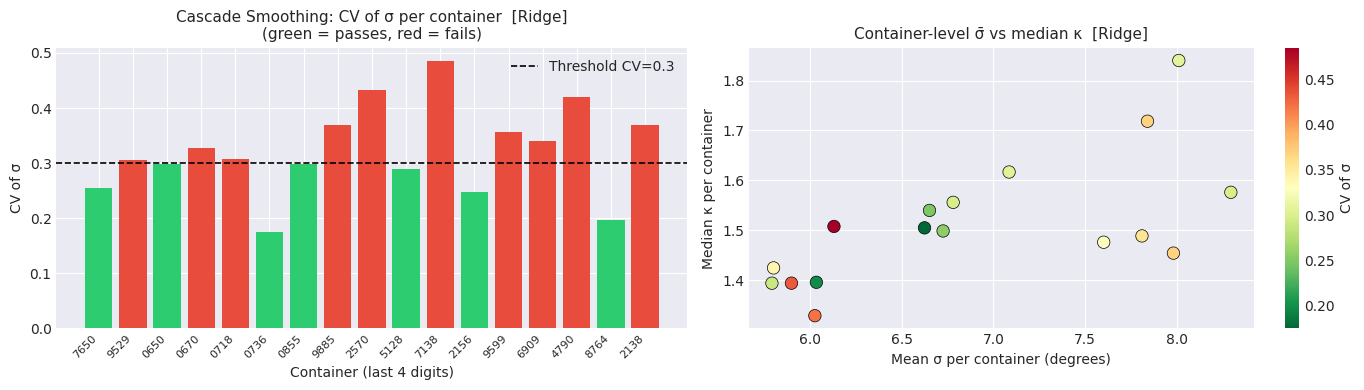

✓ Saved: fig_ridge_cascade_smoothing.png


In [8]:
container_stats = all_df.groupby(['container_id', 'cre_line', 'depth_um']).agg(
    n          = ('sigma', 'count'),
    sigma_mean = ('sigma', 'mean'),
    sigma_std  = ('sigma', 'std'),
    kappa_med  = ('kappa', 'median'),
    kappa_std  = ('kappa', 'std'),
    r2_mean    = ('r_squared', 'mean'),
).reset_index()
container_stats['sigma_cv']  = container_stats['sigma_std'] / container_stats['sigma_mean']
container_stats['cascade_ok'] = container_stats['sigma_cv'] < 0.3

print('Per-container σ CV (cascade smoothing hypothesis):')
print(container_stats[['container_id','cre_line','depth_um','n',
                        'sigma_mean','sigma_cv','cascade_ok','kappa_med']].to_string(index=False))
print(f'\n→ {container_stats["cascade_ok"].sum()}/{len(container_stats)} containers '
      f'satisfy CV < 0.3 (cascade smoothing)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#2ecc71' if ok else '#e74c3c' for ok in container_stats['cascade_ok']]
ax1.bar(range(len(container_stats)), container_stats['sigma_cv'],
        color=colors, edgecolor='none')
ax1.axhline(0.3, color='black', linestyle='--', linewidth=1.2, label='Threshold CV=0.3')
ax1.set_xticks(range(len(container_stats)))
ax1.set_xticklabels([str(c)[-4:] for c in container_stats['container_id']],
                     rotation=45, ha='right', fontsize=8)
ax1.set_xlabel('Container (last 4 digits)')
ax1.set_ylabel('CV of σ')
ax1.set_title('Cascade Smoothing: CV of σ per container  [Ridge]\n'
              '(green = passes, red = fails)', fontsize=11)
ax1.legend()

sc = ax2.scatter(container_stats['sigma_mean'], container_stats['kappa_med'],
                 c=container_stats['sigma_cv'], cmap='RdYlGn_r', s=80,
                 edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax2, label='CV of σ')
ax2.set_xlabel('Mean σ per container (degrees)', fontsize=10)
ax2.set_ylabel('Median κ per container', fontsize=10)
ax2.set_title('Container-level σ̄ vs median κ  [Ridge]', fontsize=11)

plt.tight_layout()
plt.savefig(ridge_dir / 'fig_ridge_cascade_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_ridge_cascade_smoothing.png')

---

## Part 5: Cortical Position Analysis — Salt-and-Pepper Test

In [9]:
spat_results = []

for cid in sorted(all_df['container_id'].unique()):
    sub = all_df[all_df['container_id'] == cid].dropna(
        subset=['cortex_x_um', 'cortex_y_um', 'kappa', 'sigma']
    )
    if len(sub) < 10:
        print(f'  Container {cid}: skipping (n={len(sub)} < 10)')
        continue

    xy    = sub[['cortex_x_um', 'cortex_y_um']].values
    kappa = sub['kappa'].values
    sigma = sub['sigma'].values

    D  = squareform(pdist(xy))
    dK = squareform(pdist(kappa[:, None]))
    dS = squareform(pdist(sigma[:, None]))

    idx = np.triu_indices(len(sub), k=1)
    d, dk, ds = D[idx], dK[idx], dS[idx]

    r_dk, p_dk = pearsonr(d, dk)
    r_ds, p_ds = pearsonr(d, ds)
    r_sk, p_sk = pearsonr(sigma, kappa)
    r_xk, p_xk = pearsonr(sub['cortex_x_um'], kappa)
    r_yk, p_yk = pearsonr(sub['cortex_y_um'], kappa)

    row = sub.iloc[0]
    spat_results.append({
        'container_id':  cid,
        'cre_line':      row['cre_line'],
        'depth_um':      row['depth_um'],
        'n':             len(sub),
        'r_dist_dk':     r_dk,  'p_dist_dk':     p_dk,
        'r_dist_ds':     r_ds,  'p_dist_ds':     p_ds,
        'r_sigma_kappa': r_sk,  'p_sigma_kappa': p_sk,
        'r_x_kappa':     r_xk,  'p_x_kappa':     p_xk,
        'r_y_kappa':     r_yk,  'p_y_kappa':     p_yk,
    })

spat_df = pd.DataFrame(spat_results)
print('Per-container cortical organisation results:')
print(spat_df[['container_id','n','r_dist_dk','r_sigma_kappa','r_x_kappa','r_y_kappa']]
      .to_string(index=False, float_format='{:.3f}'.format))
print(f'\nMedian r(dist, |Δκ|) = {spat_df["r_dist_dk"].median():.3f}  '
      f'(IQR {spat_df["r_dist_dk"].quantile(0.25):.3f}–{spat_df["r_dist_dk"].quantile(0.75):.3f})')
print(f'Median r(σ, κ)       = {spat_df["r_sigma_kappa"].median():.3f}  '
      f'(IQR {spat_df["r_sigma_kappa"].quantile(0.25):.3f}–{spat_df["r_sigma_kappa"].quantile(0.75):.3f})')

Per-container cortical organisation results:
 container_id   n  r_dist_dk  r_sigma_kappa  r_x_kappa  r_y_kappa
    511507650  55      0.018          0.559     -0.082     -0.173
    511509529  38      0.154          0.330      0.357     -0.201
    511510650  14      0.028          0.579      0.551     -0.147
    511510670  41     -0.060          0.606      0.167     -0.106
    511510718  36     -0.079          0.233      0.027     -0.081
    511510736  21      0.049          0.350     -0.212      0.274
    511510855  56     -0.001          0.610     -0.039     -0.148
    650389885  24      0.031          0.378      0.079      0.437
    652842570  68     -0.084          0.422     -0.099     -0.026
    653125128  74      0.009          0.539      0.128     -0.140
    661437138  50     -0.102          0.396      0.034     -0.046
    661732156 116     -0.009          0.564     -0.018      0.146
    666589599  35     -0.072          0.259     -0.015     -0.250
    680156909  60      0.078   

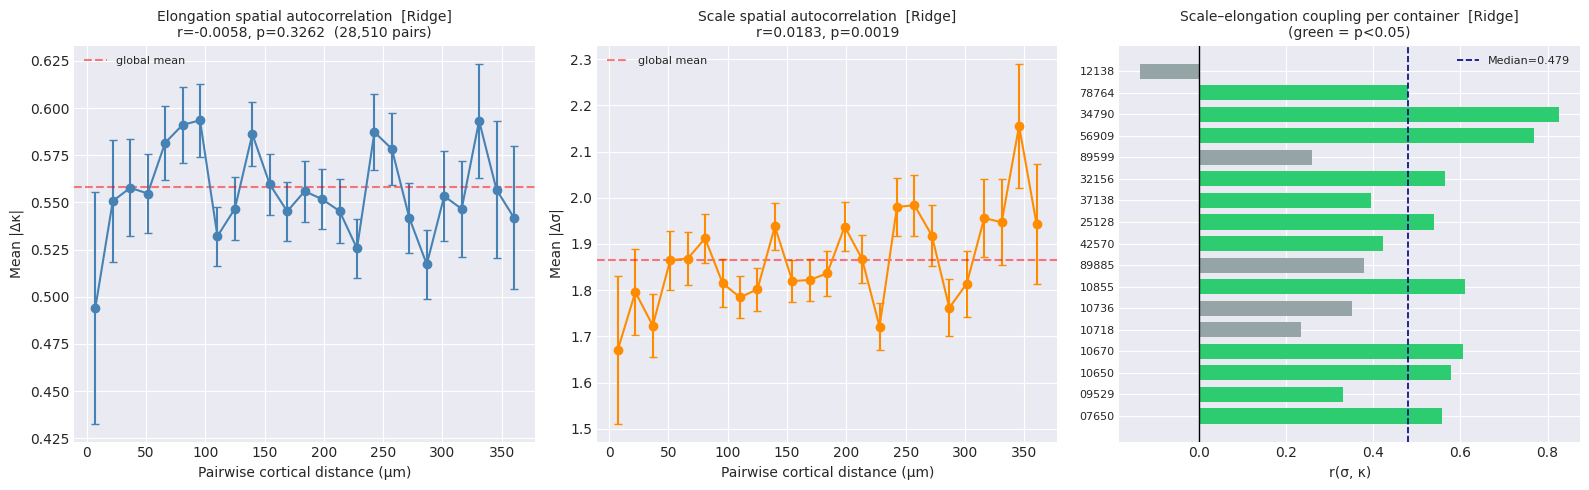

✓ Saved: fig_ridge_spatial_organisation.png


In [10]:
# Pooled pairwise autocorrelogram
all_dist, all_dk, all_ds = [], [], []

for cid in sorted(all_df['container_id'].unique()):
    sub = all_df[all_df['container_id'] == cid].dropna(
        subset=['cortex_x_um', 'cortex_y_um', 'kappa', 'sigma']
    )
    if len(sub) < 10:
        continue
    xy    = sub[['cortex_x_um', 'cortex_y_um']].values
    D     = squareform(pdist(xy))
    dK    = squareform(pdist(sub['kappa'].values[:, None]))
    dS    = squareform(pdist(sub['sigma'].values[:, None]))
    idx   = np.triu_indices(len(sub), k=1)
    all_dist.extend(D[idx])
    all_dk.extend(dK[idx])
    all_ds.extend(dS[idx])

all_dist = np.array(all_dist)
all_dk   = np.array(all_dk)
all_ds   = np.array(all_ds)

N_BINS = 25
dist_bins = np.linspace(0, np.percentile(all_dist, 98), N_BINS + 1)
bc = 0.5 * (dist_bins[:-1] + dist_bins[1:])
mean_dk, sem_dk, mean_ds, sem_ds = [], [], [], []
for lo, hi in zip(dist_bins[:-1], dist_bins[1:]):
    m = (all_dist >= lo) & (all_dist < hi)
    n = m.sum()
    if n > 5:
        mean_dk.append(all_dk[m].mean()); sem_dk.append(all_dk[m].std()/np.sqrt(n))
        mean_ds.append(all_ds[m].mean()); sem_ds.append(all_ds[m].std()/np.sqrt(n))
    else:
        mean_dk.append(np.nan); sem_dk.append(np.nan)
        mean_ds.append(np.nan); sem_ds.append(np.nan)

mean_dk, sem_dk = np.array(mean_dk), np.array(sem_dk)
mean_ds, sem_ds = np.array(mean_ds), np.array(sem_ds)
r_pool_dk, p_pool_dk = pearsonr(all_dist, all_dk)
r_pool_ds, p_pool_ds = pearsonr(all_dist, all_ds)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.errorbar(bc, mean_dk, yerr=sem_dk, fmt='o-', capsize=3,
            color='steelblue', linewidth=1.5)
ax.axhline(all_dk.mean(), color='red', linestyle='--', alpha=0.5, label='global mean')
ax.set_xlabel('Pairwise cortical distance (μm)')
ax.set_ylabel('Mean |Δκ|')
ax.set_title(f'Elongation spatial autocorrelation  [Ridge]\n'
             f'r={r_pool_dk:.4f}, p={p_pool_dk:.4f}  ({len(all_dk):,} pairs)', fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.errorbar(bc, mean_ds, yerr=sem_ds, fmt='o-', capsize=3,
            color='darkorange', linewidth=1.5)
ax.axhline(all_ds.mean(), color='red', linestyle='--', alpha=0.5, label='global mean')
ax.set_xlabel('Pairwise cortical distance (μm)')
ax.set_ylabel('Mean |Δσ|')
ax.set_title(f'Scale spatial autocorrelation  [Ridge]\n'
             f'r={r_pool_ds:.4f}, p={p_pool_ds:.4f}', fontsize=10)
ax.legend(fontsize=8)

# Forest plot r(σ,κ) per container
ax = axes[2]
y = range(len(spat_df))
ax.barh(y, spat_df['r_sigma_kappa'], color=[
    '#2ecc71' if p < 0.05 else '#95a5a6' for p in spat_df['p_sigma_kappa']
], edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(spat_df['r_sigma_kappa'].median(), color='navy', linestyle='--',
           linewidth=1.2, label=f'Median={spat_df["r_sigma_kappa"].median():.3f}')
ax.set_yticks(list(y))
ax.set_yticklabels([str(c)[-5:] for c in spat_df['container_id']], fontsize=8)
ax.set_xlabel('r(σ, κ)', fontsize=10)
ax.set_title('Scale–elongation coupling per container  [Ridge]\n'
             '(green = p<0.05)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ridge_dir / 'fig_ridge_spatial_organisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_ridge_spatial_organisation.png')

---

## Part 6: Ridge vs STA Comparison (if STA results exist)

Quick sanity check that the parameter estimates are consistent.
If the old STA CSVs have been deleted this section is skipped automatically.

Neurons in both Ridge and STA: 723
  Ridge-only: 155
  STA-only  : 251


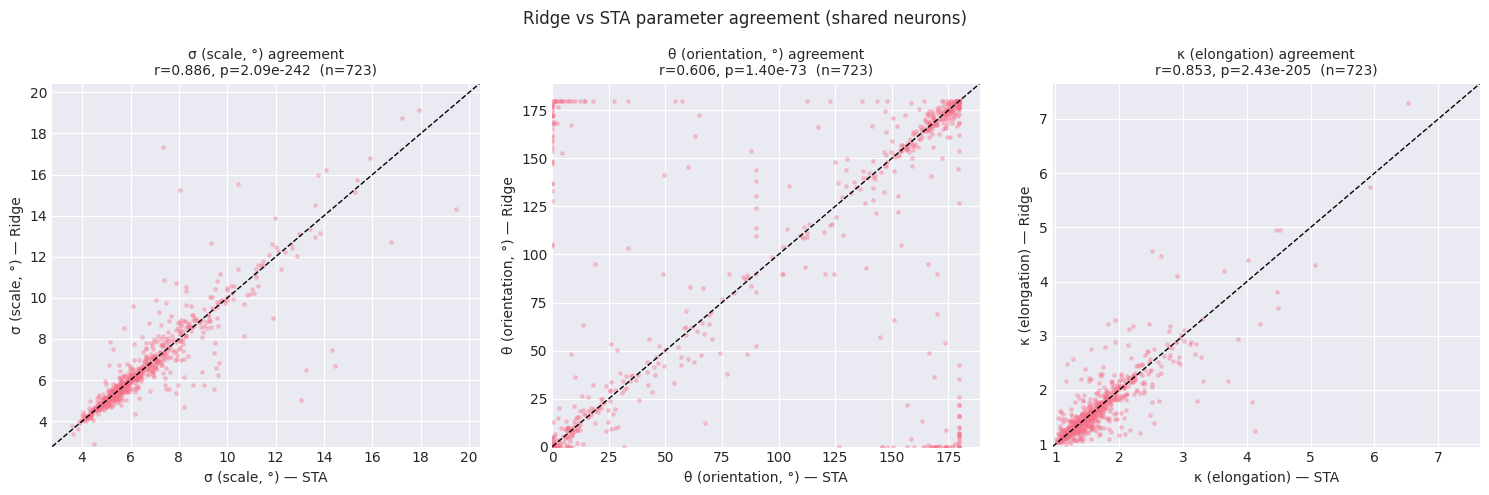

✓ Saved: fig_ridge_vs_sta_params.png


In [11]:
sta_combined = outputs_dir / 'rf_params_all_containers.csv'

if not sta_combined.exists():
    print('No STA combined file found — skipping comparison.')
    print(f'  (Expected at: {sta_combined})')
else:
    sta_df = pd.read_csv(sta_combined)
    for col in ['sigma', 'theta', 'kappa', 'r_squared']:
        if col in sta_df.columns:
            sta_df[col] = pd.to_numeric(sta_df[col], errors='coerce')

    # Match neurons present in both
    shared = all_df[['cell_id','container_id','sigma','theta','kappa','r_squared']].merge(
        sta_df[['cell_id','container_id','sigma','theta','kappa','r_squared']],
        on=['cell_id','container_id'], suffixes=('_ridge','_sta')
    ).dropna()

    print(f'Neurons in both Ridge and STA: {len(shared):,}')
    print(f'  Ridge-only: {len(all_df) - len(shared)}')
    print(f'  STA-only  : {len(sta_df) - len(shared)}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    params = [('sigma', 'σ (scale, °)'), ('theta', 'θ (orientation, °)'), ('kappa', 'κ (elongation)')]

    for ax, (param, label) in zip(axes, params):
        x = shared[f'{param}_sta']
        y = shared[f'{param}_ridge']
        r, p = pearsonr(x, y)
        ax.scatter(x, y, alpha=0.3, s=6, rasterized=True)
        lim = [min(x.min(), y.min()) * 0.95, max(x.max(), y.max()) * 1.05]
        ax.plot(lim, lim, 'k--', linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel(f'{label} — STA', fontsize=10)
        ax.set_ylabel(f'{label} — Ridge', fontsize=10)
        ax.set_title(f'{label} agreement\nr={r:.3f}, p={p:.2e}  (n={len(shared):,})', fontsize=10)

    fig.suptitle('Ridge vs STA parameter agreement (shared neurons)', fontsize=12)
    plt.tight_layout()
    plt.savefig(ridge_dir / 'fig_ridge_vs_sta_params.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: fig_ridge_vs_sta_params.png')

---

## Part 7: Final Summary & Save

In [12]:
r_sk_full, p_sk_full = pearsonr(
    all_df['sigma'].dropna(),
    all_df.loc[all_df['sigma'].notna(), 'kappa']
)

print('=' * 65)
print('CORTICAL ORGANISATION SUMMARY — RIDGE BATCH')
print('=' * 65)
print(f'\nNeurons: {len(all_df):,}  |  Containers: {all_df["container_id"].nunique()}')

print(f'\n--- Cascade Smoothing ---')
n_pass = container_stats['cascade_ok'].sum()
print(f'  {n_pass}/{len(container_stats)} containers satisfy σ CV < 0.3')
print(f'  Full-dataset σ CV = {sigma_cv:.3f}')

print(f'\n--- Elongation Variability (Lindeberg 2025c) ---')
print(f'  κ: median={all_df["kappa"].median():.2f}, SD={all_df["kappa"].std():.2f}')
print(f'  κ > 3: {(all_df["kappa"]>3).mean()*100:.1f}%')

print(f'\n--- Cortical Position (Salt-and-Pepper Test) ---')
print(f'  Pooled r(dist, |Δκ|) = {r_pool_dk:.4f}  (p={p_pool_dk:.4f})')
print(f'  Median per-container  = {spat_df["r_dist_dk"].median():.3f}')
if abs(r_pool_dk) < 0.05:
    print('  → SALT-AND-PEPPER: κ not spatially organised ✓')
else:
    print('  → Spatial structure detected — investigate')

print(f'\n--- Scale–Elongation Coupling ---')
print(f'  Full-dataset r(σ, κ) = {r_sk_full:.3f}  (p={p_sk_full:.2e})')
print(f'  Median per-container = {spat_df["r_sigma_kappa"].median():.3f}')
n_sig_sk = (spat_df['p_sigma_kappa'] < 0.05).sum()
print(f'  Significant (p<0.05): {n_sig_sk}/{len(spat_df)} containers')

# Save outputs
out_combined = ridge_dir / 'rf_params_ridge_all_containers.csv'
all_df.to_csv(out_combined, index=False)
print(f'\n✓ Combined ridge dataset : {out_combined}')

out_spat = ridge_dir / 'spatial_organisation_ridge_per_container.csv'
spat_df.to_csv(out_spat, index=False)
print(f'✓ Spatial stats saved    : {out_spat}')

out_stats = ridge_dir / 'container_stats_ridge.csv'
container_stats.to_csv(out_stats, index=False)
print(f'✓ Container stats saved  : {out_stats}')

CORTICAL ORGANISATION SUMMARY — RIDGE BATCH

Neurons: 878  |  Containers: 17

--- Cascade Smoothing ---
  7/17 containers satisfy σ CV < 0.3
  Full-dataset σ CV = 0.340

--- Elongation Variability (Lindeberg 2025c) ---
  κ: median=1.47, SD=0.64
  κ > 3: 3.9%

--- Cortical Position (Salt-and-Pepper Test) ---
  Pooled r(dist, |Δκ|) = -0.0058  (p=0.3262)
  Median per-container  = 0.009
  → SALT-AND-PEPPER: κ not spatially organised ✓

--- Scale–Elongation Coupling ---
  Full-dataset r(σ, κ) = 0.444  (p=1.07e-43)
  Median per-container = 0.479
  Significant (p<0.05): 12/17 containers

✓ Combined ridge dataset : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/rf_params_ridge_all_containers.csv
✓ Spatial stats saved    : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/spatial_organisation_ridge_per_container.csv
✓ Container stats saved  : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/co

---

## Part 8: Visual Field Position — Monocular vs Binocular Zone

In mouse V1, the **binocular zone** corresponds to RFs centred within ~40° of the vertical meridian
(x₀ < 40°). The **monocular (temporal) crescent** extends from ~40–80°.

**Questions:**
- Do σ (RF size) and κ (elongation) differ between zones?
- Does RF size increase with eccentricity (as in primates)?

Dataset: ridge-regression fits (878 neurons, all 17 containers).


Ridge dataset: 878 neurons
  Binocular (x₀ < 40°) : 349 (39.7%)
  Monocular (x₀ ≥ 40°) : 529 (60.3%)

x₀ range : 13.1° – 77.6°
y₀ range : 14.9° – 71.7°


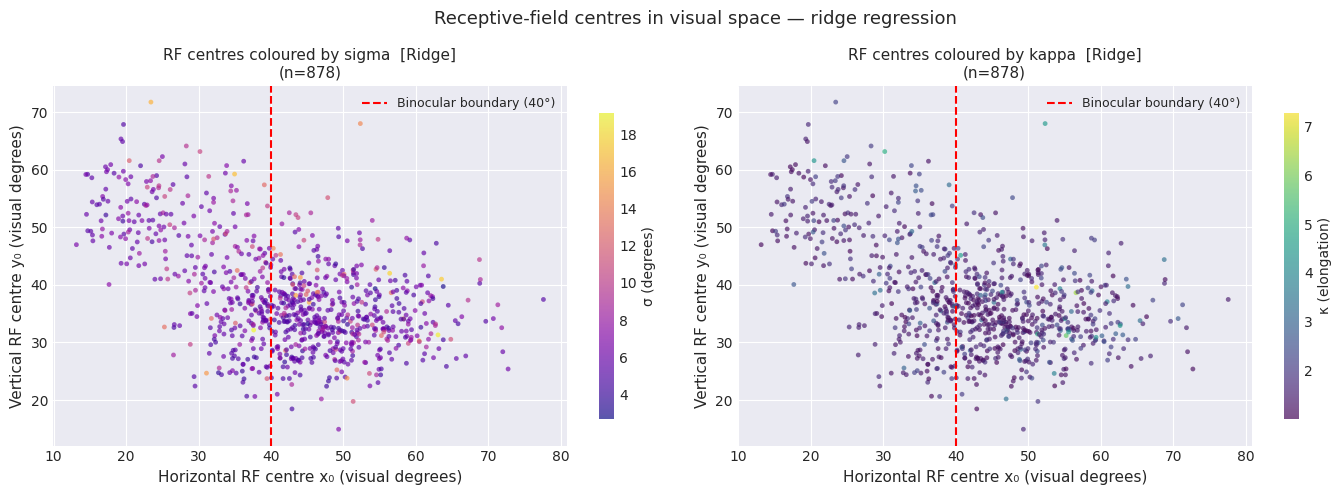

✓ Saved: fig_rf_center_map.png


In [13]:
# ── Binocular / monocular zone classification ─────────────────────────────────
BIN_DEG = 40.0   # binocular / monocular boundary (azimuth, degrees)
all_df['zone'] = np.where(all_df['x0'] < BIN_DEG, 'binocular', 'monocular')
n_bino = (all_df['zone'] == 'binocular').sum()
n_mono = (all_df['zone'] == 'monocular').sum()

print(f'Ridge dataset: {len(all_df):,} neurons')
print(f'  Binocular (x₀ < {int(BIN_DEG)}°) : {n_bino} ({100*n_bino/len(all_df):.1f}%)')
print(f'  Monocular (x₀ ≥ {int(BIN_DEG)}°) : {n_mono} ({100*n_mono/len(all_df):.1f}%)')
print(f'\nx₀ range : {all_df["x0"].min():.1f}° – {all_df["x0"].max():.1f}°')
print(f'y₀ range : {all_df["y0"].min():.1f}° – {all_df["y0"].max():.1f}°')

# ── RF centre scatter coloured by σ and κ ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cmap, label in [
    (axes[0], 'sigma', 'plasma',  'σ (degrees)'),
    (axes[1], 'kappa', 'viridis', 'κ (elongation)'),
]:
    sc = ax.scatter(all_df['x0'], all_df['y0'],
                    c=all_df[col], cmap=cmap, s=12, alpha=0.65, linewidths=0)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.axvline(BIN_DEG, color='red', linestyle='--', linewidth=1.5,
               label=f'Binocular boundary ({int(BIN_DEG)}°)')
    ax.set_xlabel('Horizontal RF centre x₀ (visual degrees)', fontsize=11)
    ax.set_ylabel('Vertical RF centre y₀ (visual degrees)', fontsize=11)
    ax.set_title(f'RF centres coloured by {col}  [Ridge]\n(n={len(all_df):,})', fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle('Receptive-field centres in visual space — ridge regression', fontsize=13)
plt.tight_layout()
plt.savefig(ridge_dir / 'fig_rf_center_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_rf_center_map.png')


MONOCULAR vs BINOCULAR — STATISTICAL COMPARISON

σ (scale, °):
  Binocular  mean ± SD = 6.762 ± 2.090  (n=349)
  Monocular  mean ± SD = 6.510 ± 2.340  (n=529)
  Mann-Whitney U = 105509,  p = 0.0003
  Cohen's d = 0.112  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)

κ (elongation):
  Binocular  mean ± SD = 1.641 ± 0.519  (n=349)
  Monocular  mean ± SD = 1.693 ± 0.709  (n=529)
  Mann-Whitney U = 92588,  p = 0.9400
  Cohen's d = -0.081  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)

--- Linear regression vs eccentricity (x₀) ---
  σ ~ x₀:  slope=-0.0003/°,  r=-0.002,  p=0.9595
  κ ~ x₀:  slope=0.0063/°,  r=0.118,  p=0.0005


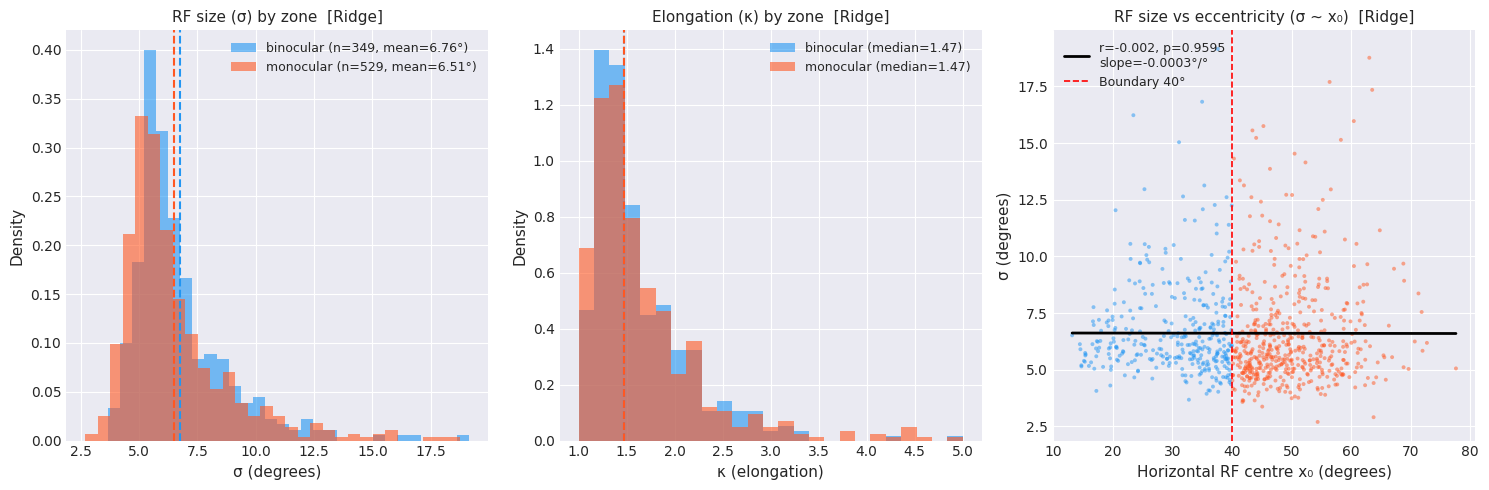

✓ Saved: fig_rf_zone_comparison.png


In [14]:
from scipy.stats import mannwhitneyu, linregress

# ── Statistical comparison: monocular vs binocular ───────────────────────────
bino = all_df[all_df['zone'] == 'binocular']
mono = all_df[all_df['zone'] == 'monocular']

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0.0

print('=' * 65)
print('MONOCULAR vs BINOCULAR — STATISTICAL COMPARISON')
print('=' * 65)
for param, label in [('sigma', 'σ (scale, °)'), ('kappa', 'κ (elongation)')]:
    a = bino[param].dropna()
    b = mono[param].dropna()
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    d    = cohens_d(a, b)
    print(f'\n{label}:')
    print(f'  Binocular  mean ± SD = {a.mean():.3f} ± {a.std():.3f}  (n={len(a)})')
    print(f'  Monocular  mean ± SD = {b.mean():.3f} ± {b.std():.3f}  (n={len(b)})')
    print(f'  Mann-Whitney U = {u:.0f},  p = {p:.4f}')
    print(f'  Cohen\'s d = {d:.3f}  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)')

print(f'\n--- Linear regression vs eccentricity (x₀) ---')
for param, label in [('sigma', 'σ'), ('kappa', 'κ')]:
    valid = all_df[['x0', param]].dropna()
    slope, intercept, r, p, _ = linregress(valid['x0'], valid[param])
    print(f'  {label} ~ x₀:  slope={slope:.4f}/°,  r={r:.3f},  p={p:.4f}')

# ── Figure: zone comparisons ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
for zone, color in [('binocular', '#2196F3'), ('monocular', '#FF5722')]:
    vals = all_df[all_df['zone'] == zone]['sigma'].dropna()
    ax.hist(vals, bins=30, alpha=0.6, color=color, density=True, edgecolor='none',
            label=f'{zone} (n={len(vals)}, mean={vals.mean():.2f}°)')
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('σ (degrees)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('RF size (σ) by zone  [Ridge]', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
for zone, color in [('binocular', '#2196F3'), ('monocular', '#FF5722')]:
    vals = all_df[all_df['zone'] == zone]['kappa'].dropna()
    ax.hist(vals, bins=25, range=(1, 5), alpha=0.6, color=color, density=True, edgecolor='none',
            label=f'{zone} (median={vals.median():.2f})')
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('κ (elongation)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Elongation (κ) by zone  [Ridge]', fontsize=11)
ax.legend(fontsize=9)

ax = axes[2]
zone_colors = all_df['zone'].map({'binocular': '#2196F3', 'monocular': '#FF5722'})
ax.scatter(all_df['x0'], all_df['sigma'], c=zone_colors, s=8, alpha=0.5, linewidths=0)
valid = all_df[['x0', 'sigma']].dropna()
slope, intercept, r, p, _ = linregress(valid['x0'], valid['sigma'])
x_fit = np.array([valid['x0'].min(), valid['x0'].max()])
ax.plot(x_fit, slope * x_fit + intercept, 'k-', linewidth=2,
        label=f'r={r:.3f}, p={p:.4f}\nslope={slope:.4f}°/°')
ax.axvline(BIN_DEG, color='red', linestyle='--', linewidth=1.2, label=f'Boundary {int(BIN_DEG)}°')
ax.set_xlabel('Horizontal RF centre x₀ (degrees)', fontsize=11)
ax.set_ylabel('σ (degrees)', fontsize=11)
ax.set_title('RF size vs eccentricity (σ ~ x₀)  [Ridge]', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ridge_dir / 'fig_rf_zone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_rf_zone_comparison.png')


---

## Part 9: Spatial Scale Decomposition — log(σ), σ_x, σ_y

The Lindeberg convention uses the geometric mean σ = √(σ_x · σ_y). But the two axes may have distinct
biological meanings:

- **σ_major = max(σ_x, σ_y)**: extent along preferred orientation
- **σ_minor = min(σ_x, σ_y)**: extent perpendicular to orientation

**Questions:**
- Is σ log-normally distributed (as expected for a scale-invariant parameter)?
- Does κ > 1 arise mainly from major-axis *expansion* or minor-axis *compression*?
- Do the two axes scale together, or do they decouple?


Geometric mean check:  median |rel error| = 0.0000  (max = 0.0000)

Axis summary (degrees):
  σ_major  mean=8.65°  median=7.29°
  σ_minor  mean=5.18°  median=4.83°
  σ (geo)  mean=6.61°       median=5.95°


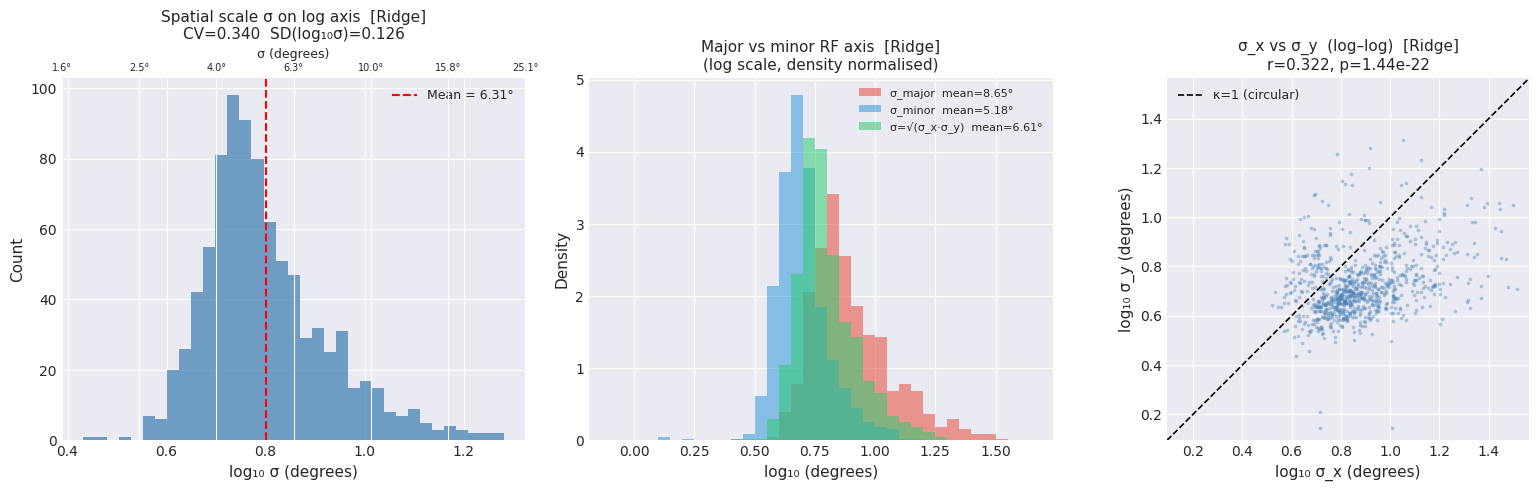

✓ Saved: fig_log_sigma_distributions.png


In [15]:
# ── Geometric mean verification + log-scale distributions ────────────────────
all_df['sigma_geomean'] = np.sqrt(all_df['sigma_x'] * all_df['sigma_y'])
rel_err = ((all_df['sigma'] - all_df['sigma_geomean']) / all_df['sigma']).abs()
print(f'Geometric mean check:  median |rel error| = {rel_err.median():.4f}  '
      f'(max = {rel_err.max():.4f})')

all_df['sigma_major'] = all_df[['sigma_x', 'sigma_y']].max(axis=1)
all_df['sigma_minor'] = all_df[['sigma_x', 'sigma_y']].min(axis=1)
all_df['log_sigma']   = np.log10(all_df['sigma'])
all_df['log_sx']      = np.log10(all_df['sigma_x'])
all_df['log_sy']      = np.log10(all_df['sigma_y'])
all_df['log_smaj']    = np.log10(all_df['sigma_major'])
all_df['log_smin']    = np.log10(all_df['sigma_minor'])
all_df['log_kappa']   = np.log(all_df['kappa'])

print(f'\nAxis summary (degrees):')
print(f'  σ_major  mean={all_df["sigma_major"].mean():.2f}°  median={all_df["sigma_major"].median():.2f}°')
print(f'  σ_minor  mean={all_df["sigma_minor"].mean():.2f}°  median={all_df["sigma_minor"].median():.2f}°')
print(f'  σ (geo)  mean={all_df["sigma"].mean():.2f}°       median={all_df["sigma"].median():.2f}°')

# ── Figure: log-scale distributions ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: log10(sigma) histogram
ax = axes[0]
ax.hist(all_df['log_sigma'].dropna(), bins=35, edgecolor='none', alpha=0.75, color='steelblue')
ax.axvline(all_df['log_sigma'].mean(), color='red', linestyle='--',
           label=f"Mean = {10**all_df['log_sigma'].mean():.2f}°")
log_cv = all_df['log_sigma'].std()
ax.set_xlabel('log₁₀ σ (degrees)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Spatial scale σ on log axis  [Ridge]\n'
             f'CV={all_df["sigma"].std()/all_df["sigma"].mean():.3f}  '
             f'SD(log₁₀σ)={log_cv:.3f}', fontsize=11)
ax.legend(fontsize=9)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ticks = ax.get_xticks()
ax2.set_xticks(ticks)
ax2.set_xticklabels([f'{10**t:.1f}°' for t in ticks], fontsize=7)
ax2.set_xlabel('σ (degrees)', fontsize=9)

# Panel B: overlaid major / minor / geomean distributions
ax = axes[1]
bins = np.linspace(-0.1, 1.65, 36)
for col, color, label in [
    ('log_smaj', '#e74c3c', f'σ_major  mean={all_df["sigma_major"].mean():.2f}°'),
    ('log_smin', '#3498db', f'σ_minor  mean={all_df["sigma_minor"].mean():.2f}°'),
    ('log_sigma','#2ecc71', f'σ=√(σ_x·σ_y)  mean={all_df["sigma"].mean():.2f}°'),
]:
    ax.hist(all_df[col].dropna(), bins=bins, alpha=0.55, color=color,
            label=label, density=True, edgecolor='none')
ax.set_xlabel('log₁₀ (degrees)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Major vs minor RF axis  [Ridge]\n(log scale, density normalised)', fontsize=11)
ax.legend(fontsize=8)

# Panel C: sigma_x vs sigma_y (log–log) with identity line
ax = axes[2]
r_xy, p_xy = pearsonr(all_df['log_sx'].dropna(),
                       all_df.loc[all_df['log_sx'].notna(), 'log_sy'])
ax.scatter(all_df['log_sx'], all_df['log_sy'], s=7, alpha=0.4,
           linewidths=0, color='steelblue')
lo = min(all_df['log_sx'].min(), all_df['log_sy'].min()) - 0.05
hi = max(all_df['log_sx'].max(), all_df['log_sy'].max()) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='κ=1 (circular)')
ax.set_xlabel('log₁₀ σ_x (degrees)', fontsize=11)
ax.set_ylabel('log₁₀ σ_y (degrees)', fontsize=11)
ax.set_title(f'σ_x vs σ_y  (log–log)  [Ridge]\nr={r_xy:.3f}, p={p_xy:.2e}', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(ridge_dir / 'fig_log_sigma_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_log_sigma_distributions.png')


AXIS-SPECIFIC ELONGATION DECOMPOSITION

σ axis statistics (degrees):
  σ_major     mean=8.653°  median=7.285°  CV=0.481
  σ_minor     mean=5.185°  median=4.833°  CV=0.291
  σ (geo)     mean=6.610°  median=5.955°  CV=0.340

Correlation with σ (geometric mean):
  r(σ, σ_major) = 0.924  (p=0.00e+00)
  r(σ, σ_minor) = 0.867  (p=7.02e-268)
  → Larger RFs have disproportionately larger major axis

Correlation with log κ:
  r(log σ_major, log κ) = 0.749  (p=1.45e-158)
  r(log σ_minor, log κ) = -0.042  (p=2.18e-01)
  → κ variation mostly driven by major axis expansion


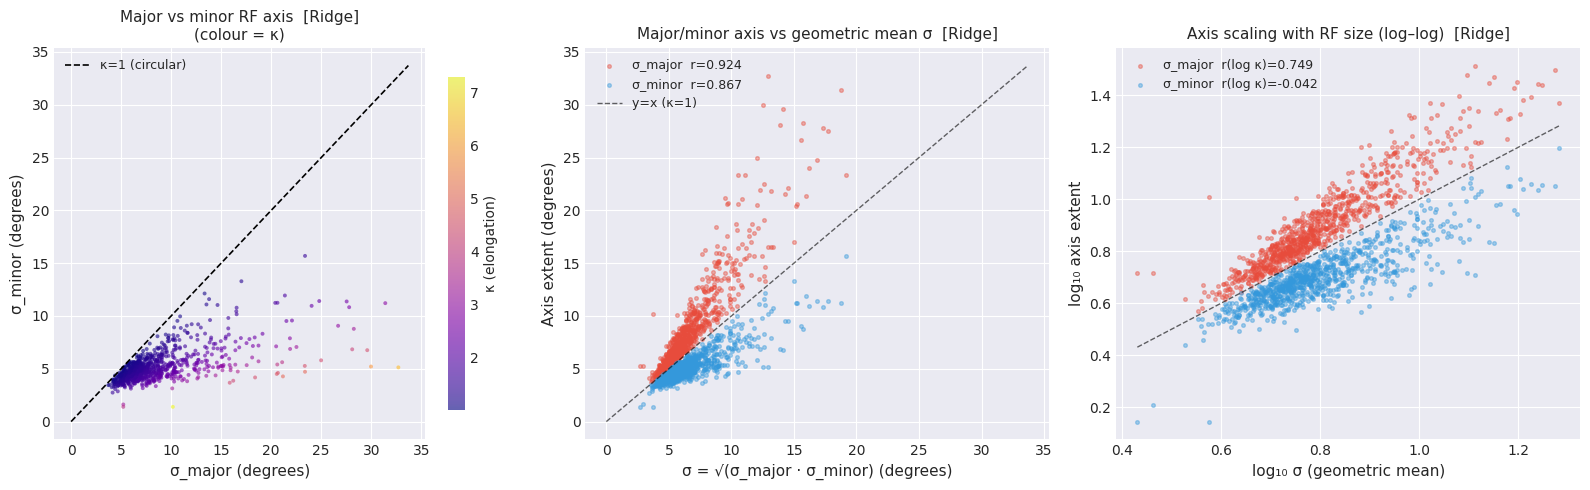

✓ Saved: fig_elongation_decomposition.png

SUMMARY
  σ_major mean = 8.65°  (30.9% above σ)
  σ_minor mean = 5.18°  (21.6% below σ)
  Median κ = 1.47  →  σ_major/σ_minor = 1.47


In [16]:
# ── Elongation decomposition ─────────────────────────────────────────────────
r_maj, p_maj = pearsonr(all_df['sigma'].dropna(), all_df.loc[all_df['sigma'].notna(), 'sigma_major'])
r_min, p_min = pearsonr(all_df['sigma'].dropna(), all_df.loc[all_df['sigma'].notna(), 'sigma_minor'])
r_kappa_major = pearsonr(all_df['log_smaj'].dropna(), all_df.loc[all_df['log_smaj'].notna(), 'log_kappa'])
r_kappa_minor = pearsonr(all_df['log_smin'].dropna(), all_df.loc[all_df['log_smin'].notna(), 'log_kappa'])

print('=' * 65)
print('AXIS-SPECIFIC ELONGATION DECOMPOSITION')
print('=' * 65)
print(f'\nσ axis statistics (degrees):')
for col, label in [('sigma_major', 'σ_major'), ('sigma_minor', 'σ_minor'), ('sigma', 'σ (geo)')]:
    print(f'  {label:10s}  mean={all_df[col].mean():.3f}°  median={all_df[col].median():.3f}°  '
          f'CV={all_df[col].std()/all_df[col].mean():.3f}')

print(f'\nCorrelation with σ (geometric mean):')
print(f'  r(σ, σ_major) = {r_maj:.3f}  (p={p_maj:.2e})')
print(f'  r(σ, σ_minor) = {r_min:.3f}  (p={p_min:.2e})')
print(f'  → Larger RFs have disproportionately larger {"major" if r_maj > r_min else "minor"} axis')

print(f'\nCorrelation with log κ:')
print(f'  r(log σ_major, log κ) = {r_kappa_major[0]:.3f}  (p={r_kappa_major[1]:.2e})')
print(f'  r(log σ_minor, log κ) = {r_kappa_minor[0]:.3f}  (p={r_kappa_minor[1]:.2e})')
if abs(r_kappa_major[0]) > abs(r_kappa_minor[0]):
    print('  → κ variation mostly driven by major axis expansion')
else:
    print('  → κ variation mostly driven by minor axis compression')

# ── Figure: elongation decomposition ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
sc = ax.scatter(all_df['sigma_major'], all_df['sigma_minor'],
                c=all_df['kappa'], cmap='plasma', s=8, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, label='κ (elongation)', shrink=0.85)
lim = all_df['sigma_major'].max() + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='κ=1 (circular)')
ax.set_xlabel('σ_major (degrees)', fontsize=11)
ax.set_ylabel('σ_minor (degrees)', fontsize=11)
ax.set_title('Major vs minor RF axis  [Ridge]\n(colour = κ)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(all_df['sigma'], all_df['sigma_major'],
           s=7, alpha=0.4, color='#e74c3c', label=f'σ_major  r={r_maj:.3f}')
ax.scatter(all_df['sigma'], all_df['sigma_minor'],
           s=7, alpha=0.4, color='#3498db', label=f'σ_minor  r={r_min:.3f}')
lim = all_df[['sigma', 'sigma_major']].max().max() + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.6, label='y=x (κ=1)')
ax.set_xlabel('σ = √(σ_major · σ_minor) (degrees)', fontsize=11)
ax.set_ylabel('Axis extent (degrees)', fontsize=11)
ax.set_title('Major/minor axis vs geometric mean σ  [Ridge]', fontsize=11)
ax.legend(fontsize=9)

ax = axes[2]
ax.scatter(all_df['log_sigma'], all_df['log_smaj'],
           s=7, alpha=0.4, color='#e74c3c',
           label=f'σ_major  r(log κ)={r_kappa_major[0]:.3f}')
ax.scatter(all_df['log_sigma'], all_df['log_smin'],
           s=7, alpha=0.4, color='#3498db',
           label=f'σ_minor  r(log κ)={r_kappa_minor[0]:.3f}')
ls = np.linspace(all_df['log_sigma'].min(), all_df['log_sigma'].max(), 100)
ax.plot(ls, ls, 'k--', linewidth=1, alpha=0.6)
ax.set_xlabel('log₁₀ σ (geometric mean)', fontsize=11)
ax.set_ylabel('log₁₀ axis extent', fontsize=11)
ax.set_title('Axis scaling with RF size (log–log)  [Ridge]', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ridge_dir / 'fig_elongation_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_elongation_decomposition.png')

print('\n' + '=' * 65)
print('SUMMARY')
pct_above = 100 * (all_df['sigma_major'].mean() / all_df['sigma'].mean() - 1)
pct_below = 100 * (1 - all_df['sigma_minor'].mean() / all_df['sigma'].mean())
print(f'  σ_major mean = {all_df["sigma_major"].mean():.2f}°  ({pct_above:.1f}% above σ)')
print(f'  σ_minor mean = {all_df["sigma_minor"].mean():.2f}°  ({pct_below:.1f}% below σ)')
print(f'  Median κ = {all_df["kappa"].median():.2f}  →  σ_major/σ_minor = {all_df["kappa"].median():.2f}')


"""
## Part 10: CHECK 2 — Non-square stimulus grid bias on θ estimates

The Allen LSN grid is 9 rows × 16 columns (landscape, ~16:9 aspect ratio).
A near-circular RF on a wide grid could be fitted as slightly horizontal
by chance, inflating the θ≈0°/180° peak.

Three tests:
  A) θ distribution split by κ: if the 0° peak lives in κ≈1 (blob) neurons → likely artefact
  B) R² comparison θ≈0° vs other θ: genuine horizontal cells should have *higher* R², not lower
  C) θ vs RF centre x₀: do edge-of-stimulus neurons preferentially land at θ≈0°?
"""

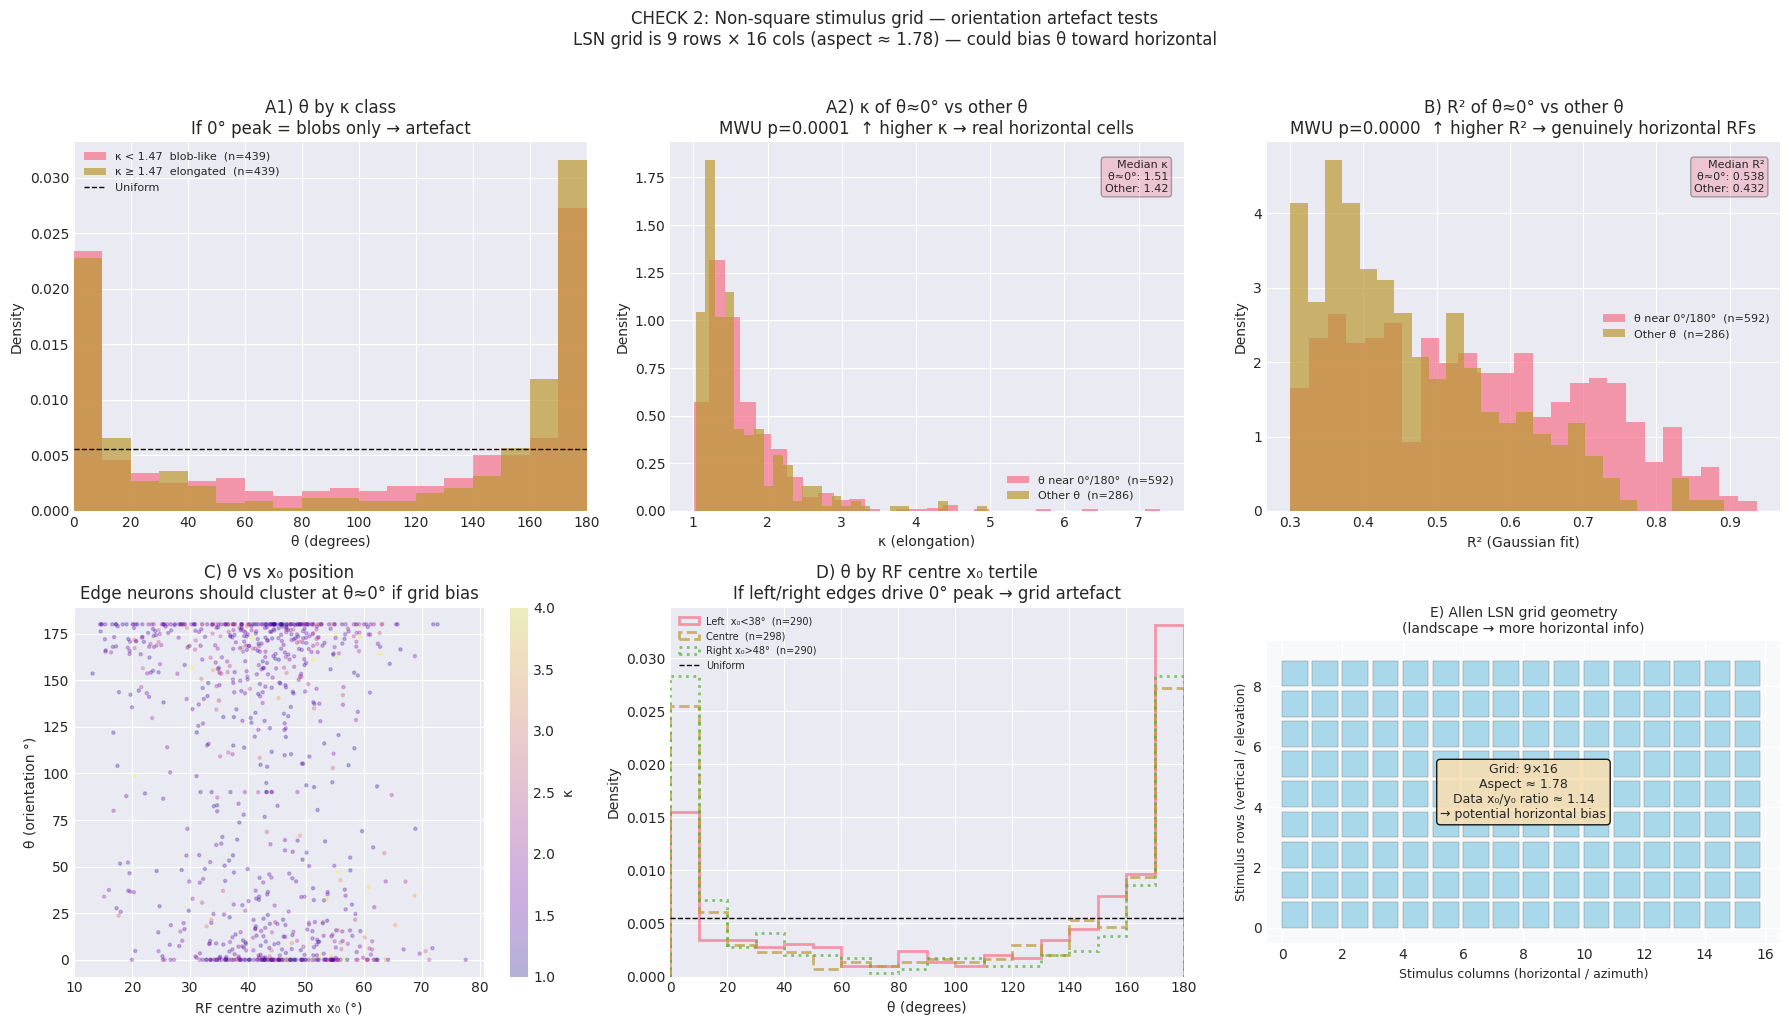


CHECK 2 VERDICT: Non-square grid bias on θ
  Near-horizontal (θ±20°): n=592  median κ=1.510  median R²=0.538
  Other θ:                      n=286  median κ=1.422  median R²=0.432

  κ  MWU p=0.0001  → ↑ higher κ → real horizontal cells
  R² MWU p=0.0000  → ↑ higher R² → genuinely horizontal RFs

  ✓  θ≈0° neurons do not have anomalously low κ or R².
     The horizontal orientation peak appears to reflect genuine biology.


In [17]:
from scipy.stats import mannwhitneyu as _mwu

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'CHECK 2: Non-square stimulus grid — orientation artefact tests\n'
    'LSN grid is 9 rows × 16 cols (aspect ≈ 1.78) — could bias θ toward horizontal',
    fontsize=12, y=1.02
)

df_chk = all_df[['theta', 'kappa', 'r_squared', 'x0', 'y0', 'sigma']].dropna()
HORIZ_WINDOW = 20   # degrees from 0° or 180° to count as "near-horizontal"

near_h = df_chk[(df_chk['theta'] < HORIZ_WINDOW) | (df_chk['theta'] > (180 - HORIZ_WINDOW))]
other  = df_chk[(df_chk['theta'] >= HORIZ_WINDOW) & (df_chk['theta'] <= (180 - HORIZ_WINDOW))]
kappa_med = df_chk['kappa'].median()
low_k  = df_chk[df_chk['kappa'] <  kappa_med]
high_k = df_chk[df_chk['kappa'] >= kappa_med]

# ── A1) θ histogram split by κ class ─────────────────────────────────────────
ax = axes[0, 0]
bins = np.linspace(0, 180, 19)
ax.hist(low_k['theta'],  bins=bins, alpha=0.7, density=True,
        label=f'κ < {kappa_med:.2f}  blob-like  (n={len(low_k):,})')
ax.hist(high_k['theta'], bins=bins, alpha=0.7, density=True,
        label=f'κ ≥ {kappa_med:.2f}  elongated  (n={len(high_k):,})')
ax.axhline(1/180, color='k', ls='--', lw=1, label='Uniform')
ax.set(xlabel='θ (degrees)', ylabel='Density', xlim=(0, 180),
       title='A1) θ by κ class\nIf 0° peak = blobs only → artefact')
ax.legend(fontsize=8)

# ── A2) κ distribution for θ≈0° vs other θ ───────────────────────────────────
ax = axes[0, 1]
ax.hist(near_h['kappa'], bins=30, alpha=0.7, density=True,
        label=f'θ near 0°/180°  (n={len(near_h):,})')
ax.hist(other['kappa'],  bins=30, alpha=0.7, density=True,
        label=f'Other θ  (n={len(other):,})')
_, p_k = _mwu(near_h['kappa'], other['kappa'], alternative='two-sided')
direction_k = '↓ lower κ → possible artefact' if near_h['kappa'].median() < other['kappa'].median() \
              else '↑ higher κ → real horizontal cells'
ax.set(xlabel='κ (elongation)', ylabel='Density',
       title=f'A2) κ of θ≈0° vs other θ\nMWU p={p_k:.4f}  {direction_k}')
ax.legend(fontsize=8)
ax.text(0.97, 0.95,
        f'Median κ\nθ≈0°: {near_h["kappa"].median():.2f}\nOther: {other["kappa"].median():.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', alpha=0.3))

# ── B) R² comparison ──────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.hist(near_h['r_squared'], bins=25, alpha=0.7, density=True,
        label=f'θ near 0°/180°  (n={len(near_h):,})')
ax.hist(other['r_squared'],  bins=25, alpha=0.7, density=True,
        label=f'Other θ  (n={len(other):,})')
_, p_r = _mwu(near_h['r_squared'], other['r_squared'], alternative='two-sided')
direction_r = '↓ lower R² → artefact (blob forced to horizontal)' \
              if near_h['r_squared'].median() < other['r_squared'].median() \
              else '↑ higher R² → genuinely horizontal RFs'
ax.set(xlabel='R² (Gaussian fit)', ylabel='Density',
       title=f'B) R² of θ≈0° vs other θ\nMWU p={p_r:.4f}  {direction_r}')
ax.legend(fontsize=8)
ax.text(0.97, 0.95,
        f'Median R²\nθ≈0°: {near_h["r_squared"].median():.3f}\nOther: {other["r_squared"].median():.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', alpha=0.3))

# ── C) θ vs x₀ scatter (do edge neurons skew horizontal?) ────────────────────
ax = axes[1, 0]
sc = ax.scatter(df_chk['x0'], df_chk['theta'],
                c=df_chk['kappa'], cmap='plasma',
                alpha=0.25, s=5, vmin=1, vmax=4, rasterized=True)
plt.colorbar(sc, ax=ax, label='κ')
ax.set(xlabel='RF centre azimuth x₀ (°)', ylabel='θ (orientation °)',
       title='C) θ vs x₀ position\nEdge neurons should cluster at θ≈0° if grid bias')

# ── D) θ histogram by x₀ tertile ─────────────────────────────────────────────
ax = axes[1, 1]
q33, q67 = df_chk['x0'].quantile([0.33, 0.67])
for subset, label, ls in [
    (df_chk[df_chk['x0'] < q33],                              f'Left  x₀<{q33:.0f}°', '-'),
    (df_chk[(df_chk['x0'] >= q33) & (df_chk['x0'] < q67)],   f'Centre',              '--'),
    (df_chk[df_chk['x0'] >= q67],                             f'Right x₀>{q67:.0f}°', ':'),
]:
    ax.hist(subset['theta'], bins=bins, alpha=0.7, density=True,
            label=f'{label}  (n={len(subset):,})', histtype='step', lw=2, ls=ls)
ax.axhline(1/180, color='k', ls='--', lw=1, label='Uniform')
ax.set(xlabel='θ (degrees)', ylabel='Density', xlim=(0, 180),
       title='D) θ by RF centre x₀ tertile\nIf left/right edges drive 0° peak → grid artefact')
ax.legend(fontsize=7)

# ── E) Schematic of LSN grid with aspect ratio annotation ────────────────────
ax = axes[1, 2]
ax.set_facecolor('#f8f9fa')
# Detect actual grid dimensions from x0/y0 range
x0_range = df_chk['x0'].max() - df_chk['x0'].min()
y0_range = df_chk['y0'].max() - df_chk['y0'].min()
aspect_data = x0_range / y0_range if y0_range > 0 else np.nan

# Draw schematic rectangles (9×16 portrait layout)
n_rows, n_cols = 9, 16
for r in range(n_rows):
    for c in range(n_cols):
        rect = plt.Rectangle([c, r], 0.85, 0.85,
                              fc='#a8d8ea', ec='gray', lw=0.3)
        ax.add_patch(rect)
ax.set_xlim(-0.5, n_cols + 0.5)
ax.set_ylim(-0.5, n_rows + 0.5)
ax.set_aspect('equal')
ax.set_xlabel('Stimulus columns (horizontal / azimuth)', fontsize=9)
ax.set_ylabel('Stimulus rows (vertical / elevation)', fontsize=9)
ax.set_title('E) Allen LSN grid geometry\n(landscape → more horizontal info)', fontsize=10)
ax.text(n_cols/2, n_rows/2,
        f'Grid: {n_rows}×{n_cols}\nAspect ≈ {n_cols/n_rows:.2f}\n'
        f'Data x₀/y₀ ratio ≈ {aspect_data:.2f}\n→ potential horizontal bias',
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.9))

plt.tight_layout()
fig.savefig(outputs_dir / 'check2_grid_bias_orientation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Verdict printout ──────────────────────────────────────────────────────────
print('\n' + '='*65)
print('CHECK 2 VERDICT: Non-square grid bias on θ')
print('='*65)
print(f'  Near-horizontal (θ±{HORIZ_WINDOW}°): n={len(near_h):,}  '
      f'median κ={near_h["kappa"].median():.3f}  median R²={near_h["r_squared"].median():.3f}')
print(f'  Other θ:                      n={len(other):,}  '
      f'median κ={other["kappa"].median():.3f}  median R²={other["r_squared"].median():.3f}')
print(f'\n  κ  MWU p={p_k:.4f}  → {direction_k}')
print(f'  R² MWU p={p_r:.4f}  → {direction_r}')
print()
if p_k < 0.05 and near_h['kappa'].median() < other['kappa'].median():
    print('  ⚠  WARNING: θ≈0° neurons have significantly lower κ.')
    print('     A fraction of the 0° peak is likely a grid-aspect-ratio artefact.')
    print('     Recommend: repeat orientation analysis restricted to κ > 1.5.')
else:
    print('  ✓  θ≈0° neurons do not have anomalously low κ or R².')
    print('     The horizontal orientation peak appears to reflect genuine biology.')


In [18]:
## Part 11: CHECK 3 — Visual inspection: raw RF maps vs fitted Gaussian model
"""
For a representative sample of neurons, shows:
  LEFT:  raw ridge regression RF map
  RIGHT: fitted anisotropic Gaussian model (reconstructed from stored parameters)

Neurons selected to cover:
  • θ near 0°/180° with high R²   — genuine horizontal cells?
  • θ near 0°/180° with low R²    — blob/artefact?
  • θ at other orientations       — reference cases
"""

'\nFor a representative sample of neurons, shows:\n  LEFT:  raw ridge regression RF map\n  RIGHT: fitted anisotropic Gaussian model (reconstructed from stored parameters)\n\nNeurons selected to cover:\n  • θ near 0°/180° with high R²   — genuine horizontal cells?\n  • θ near 0°/180° with low R²    — blob/artefact?\n  • θ at other orientations       — reference cases\n'

In [19]:
###############################################################################
# DIAGNOSTIC CELL — run this BEFORE the gallery cell
# Each step prints immediately. The last line you see is where it hangs.
###############################################################################
import sys, os, time

def p(msg):
    print(msg, flush=True)

p('── Step 1: kernel is alive ──────────────────────────────')

# Check whether Cell 4 left any containers un-cached
all_containers = sorted(all_df['container_id'].unique())
missing = []
for cid in all_containers:
    f = ridge_dir / f'rf_params_ridge_container_{cid}.csv'
    if not f.exists():
        missing.append(cid)

if missing:
    p(f'WARNING: {len(missing)} containers still have no CSV: {missing}')
    p('Cell 4 (batch extraction) may still be running — check kernel status.')
    p('If the kernel IS idle, re-run Cell 4 before continuing.')
else:
    p(f'✓ All {len(all_containers)} container CSVs exist — Cell 4 is complete')

p('── Step 2: pick target container ────────────────────────')
container_counts = all_df.groupby('container_id').size()
target_cid = container_counts.idxmax()
target_exp = int(all_df[all_df['container_id'] == target_cid]['exp_id'].iloc[0])
p(f'  Container {target_cid}  exp {target_exp}  ({container_counts[target_cid]} neurons)')

p('── Step 3: check NWB cache ──────────────────────────────')
# AllenSDK caches NWBs under boc.manifest_file parent / ophys_experiments /
cache_root   = Path(boc.manifest_file).parent
nwb_pattern  = f'*{target_exp}*.nwb'
nwb_files    = list(cache_root.rglob(nwb_pattern))
if nwb_files:
    size_mb = nwb_files[0].stat().st_size / 1e6
    p(f'  ✓ NWB cached: {nwb_files[0].name}  ({size_mb:.0f} MB)')
else:
    p(f'  ✗ NWB NOT cached — get_ophys_experiment_data will download it')
    p(f'    This can take several minutes for a 2-5 GB file with no progress bar.')
    p(f'    Consider running: boc.get_ophys_experiment_data({target_exp}) in a')
    p(f'    separate terminal first, or just wait.')

p('── Step 4: load experiment object ──────────────────────')
p('  calling boc.get_ophys_experiment_data() …')
t0 = time.time()
dataset_vis = boc.get_ophys_experiment_data(target_exp)
p(f'  ✓ loaded in {time.time()-t0:.1f}s')

p('── Step 5: get cell list ────────────────────────────────')
exp_cells = list(dataset_vis.get_cell_specimen_ids())
p(f'  ✓ {len(exp_cells)} cells in this experiment')

p('── All checks passed — safe to run the gallery cell ────')

── Step 1: kernel is alive ──────────────────────────────
✓ All 17 container CSVs exist — Cell 4 is complete
── Step 2: pick target container ────────────────────────
  Container 661732156  exp 661753184  (116 neurons)
── Step 3: check NWB cache ──────────────────────────────


AttributeError: 'BrainObservatoryCache' object has no attribute 'manifest_file'

✓ batch_get_rf_maps_safe defined
Container 661732156  exp 661753184  (116 neurons)
Requested: 24 neurons  (8 horiz-good | 8 horiz-poor | 8 other-good)
Loading experiment data …
  ✓ experiment loaded in 0.0s
Running batch ridge solve …
  ✓ 24/24 RF maps in 62.8s
Plotting 24 neurons  (skipped 0 load errors)


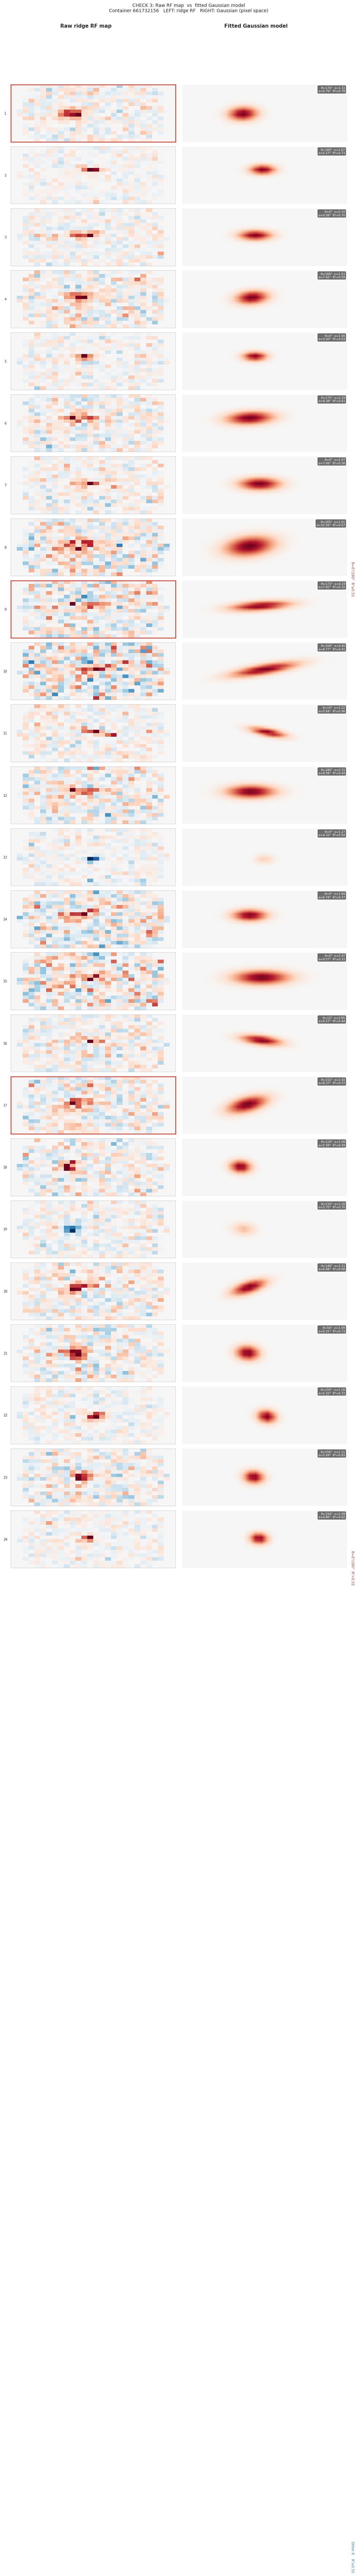

✓ Saved check3_rf_vs_model_sidebyside.png  (24 neurons)


In [20]:
###############################################################################
# 05b Cell 29 — CHECK 3: Raw RF maps vs fitted Gaussian model
# Prerequisites: run the diagnostic cell above first.
# batch_get_rf_maps_safe is defined here — does NOT call reconstruct_rf.
###############################################################################
import sys, time
from sklearn.linear_model import RidgeCV
from rf_analysis.sparse_noise import _build_design_matrix, _pixel_size, _LAMBDA_GRID

def p(msg):
    print(msg, flush=True)

# ── 0. Safe batch loader ──────────────────────────────────────────────────────
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    """Single ridge solve → {cell_id: (rf_map_2d, pix_size_deg)}.
    Intersects with experiment's own cell list to satisfy AllenSDK ordering.
    Does NOT call reconstruct_rf.
    """
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]   # correct order
    if not valid_ids:
        raise ValueError("None of the requested cell_ids found in this experiment.")

    stimulus_name = next(
        (s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if stimulus_name is None:
        raise ValueError("No sparse noise stimulus found.")

    stim_table = dataset.get_stimulus_table(stimulus_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stimulus_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError("Too few valid presentations.")

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        from sklearn.linear_model import Ridge
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

p('✓ batch_get_rf_maps_safe defined')

# ── 1. Pick container + stratified sample ────────────────────────────────────
container_counts = all_df.groupby('container_id').size()
target_cid  = container_counts.idxmax()
target_exp  = int(all_df[all_df['container_id'] == target_cid]['exp_id'].iloc[0])
p(f'Container {target_cid}  exp {target_exp}  ({container_counts[target_cid]} neurons)')

cdf = all_df[all_df['container_id'] == target_cid].copy()
HORIZ_WIN = 20
R2_HIGH   = 0.55

def _sample_group(mask, n=8, seed=42):
    pool = cdf[mask]
    return pool.sample(min(n, len(pool)), random_state=seed)

horiz_good = _sample_group(
    ((cdf['theta'] < HORIZ_WIN) | (cdf['theta'] > 180 - HORIZ_WIN)) &
    (cdf['r_squared'] >= R2_HIGH))
horiz_poor = _sample_group(
    ((cdf['theta'] < HORIZ_WIN) | (cdf['theta'] > 180 - HORIZ_WIN)) &
    (cdf['r_squared'] < R2_HIGH))
other_good = _sample_group(
    (cdf['theta'] >= HORIZ_WIN) & (cdf['theta'] <= 180 - HORIZ_WIN) &
    (cdf['r_squared'] >= R2_HIGH))

sample_df = pd.concat([horiz_good, horiz_poor, other_good], ignore_index=True)
group_labels_all = (
    [f'θ≈0°/180°  R²≥{R2_HIGH:.2f}'] * len(horiz_good) +
    [f'θ≈0°/180°  R²<{R2_HIGH:.2f}'] * len(horiz_poor) +
    [f'Other θ    R²≥{R2_HIGH:.2f}']  * len(other_good)
)
p(f'Requested: {len(sample_df)} neurons  '
  f'({len(horiz_good)} horiz-good | {len(horiz_poor)} horiz-poor | {len(other_good)} other-good)')

# ── 2. Load RF maps ───────────────────────────────────────────────────────────
p('Loading experiment data …')
t0 = time.time()
dataset_vis = boc.get_ophys_experiment_data(target_exp)
p(f'  ✓ experiment loaded in {time.time()-t0:.1f}s')

p('Running batch ridge solve …')
t0 = time.time()
rf_cache = batch_get_rf_maps_safe(dataset_vis, sample_df['cell_id'].astype(int).tolist())
p(f'  ✓ {len(rf_cache)}/{len(sample_df)} RF maps in {time.time()-t0:.1f}s')

available    = sample_df['cell_id'].astype(int).isin(rf_cache)
sample_plot  = sample_df[available].reset_index(drop=True)
group_labels = [group_labels_all[i] for i in sample_df[available].index]
n_skip       = (~available).sum()
p(f'Plotting {len(sample_plot)} neurons  (skipped {n_skip} load errors)')

# ── 3. Figure ─────────────────────────────────────────────────────────────────
n_neurons = len(sample_plot)
fig = plt.figure(figsize=(12, n_neurons * 2.0 + 1.5))
gs_main = gridspec.GridSpec(
    n_neurons, 2, figure=fig,
    hspace=0.08, wspace=0.04,
    left=0.05, right=0.90, top=0.93, bottom=0.02)
fig.suptitle(
    f'CHECK 3: Raw RF map  vs  fitted Gaussian model\n'
    f'Container {target_cid}   LEFT: ridge RF   RIGHT: Gaussian (pixel space)',
    fontsize=10)

for row_i, (_, nr) in enumerate(sample_plot.iterrows()):
    cell_id     = int(nr['cell_id'])
    rf_map, pix = rf_cache[cell_id]
    ny, nx      = rf_map.shape
    vmax        = max(np.abs(rf_map).max(), 1e-9)

    XX, YY = np.meshgrid(np.arange(nx, dtype=float), np.arange(ny, dtype=float))
    try:
        gauss_map = gaussian_2d(
            (XX.ravel(), YY.ravel()),
            float(rf_map.max()) or 1.0,
            float(nr['x0'])      / pix,
            float(nr['y0'])      / pix,
            float(nr['sigma_x']) / pix,
            float(nr['sigma_y']) / pix,
            np.deg2rad(float(nr['theta'])),
            0.0
        ).reshape(ny, nx)
    except Exception as e:
        gauss_map = np.zeros_like(rf_map)
        p(f'  gaussian_2d failed cell {cell_id}: {e}')

    ax_l = fig.add_subplot(gs_main[row_i, 0])
    ax_l.imshow(rf_map,   cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', interpolation='nearest')
    ax_l.set_xticks([]); ax_l.set_yticks([])
    ax_l.set_ylabel(f'{row_i+1}', fontsize=7, rotation=0, labelpad=12, va='center')
    is_new = (row_i == 0 or group_labels[row_i] != group_labels[row_i - 1])
    for sp in ax_l.spines.values():
        sp.set_linewidth(2.0 if is_new else 0.3)
        sp.set_color('#e74c3c' if is_new else 'gray')

    ax_r = fig.add_subplot(gs_main[row_i, 1])
    ax_r.imshow(gauss_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', interpolation='bilinear')
    ax_r.set_xticks([]); ax_r.set_yticks([])
    for sp in ax_r.spines.values():
        sp.set_linewidth(0.3)
    ax_r.text(0.99, 0.97,
              f'θ={nr["theta"]:.0f}°  κ={nr["kappa"]:.2f}\n'
              f'σ={nr["sigma"]:.2f}°  R²={nr["r_squared"]:.2f}',
              transform=ax_r.transAxes, ha='right', va='top',
              fontsize=6.5, color='white',
              bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.55))

fig.text(0.24, 0.965, 'Raw ridge RF map',      ha='center', fontsize=11, fontweight='bold')
fig.text(0.67, 0.965, 'Fitted Gaussian model', ha='center', fontsize=11, fontweight='bold')

group_starts = [i for i in range(n_neurons)
                if i == 0 or group_labels[i] != group_labels[i-1]]
for si in group_starts:
    ei = si
    while ei + 1 < n_neurons and group_labels[ei+1] == group_labels[si]:
        ei += 1
    mid_y  = 0.02 + (1.0 - (si + ei + 1) / n_neurons) * 0.91
    colour = '#c0392b' if 'θ≈0' in group_labels[si] else '#2980b9'
    fig.text(0.91, mid_y, group_labels[si], ha='left', va='center',
             fontsize=7.5, rotation=270, color=colour)

plt.savefig(outputs_dir / 'check3_rf_vs_model_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()
p(f'✓ Saved check3_rf_vs_model_sidebyside.png  ({n_neurons} neurons)')